# SMCtrl_Phase0_Pre-Processing and Data Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path
import statsmodels.api as sm
import struct
import random

from smctrl import phase, HELPER, kinematics, condition_mapping
from smctrl.scripts import run_chop_valid_data, run_collision_correction, run_timerectify_resample_and_filter

%load_ext autoreload
%autoreload 2

In [2]:
current_phase = phase.Phase("phase0")

# overall condition dictionary, dont change
condition_dict={
    0: (0, 1.7, 1.5, 1),
    1: (0, 1.7 ,2, 1),
    2: (0, 1.7 ,2.5, 1),
    3: (0, 1.7 ,2, 0.38),
    4: (0, 1.7 ,2.5, 0.38),
    5: (0, 1.7 ,2, 1.4),
    6: (0, 1.7 ,2.5, 1.4)
}

conditon_mapper = condition_mapping.CONDITION_MAPPING(condition_dict)

modality = {
    "IsHand":1, 
    "IsFinger":1, 
    "IsEye":1,
    "IsEMG":1, 
    "IsEEG":1, 
    "IsDart":1
}


In [3]:
# Subject to analyze
sub_nums = [11]
# electrod = "UnityRawEngine" # "LowImp", "HighImp", "AgElec", None
electrod = "" # "LowImp", "HighImp", "AgElec", None

base_dir = Path(f"{current_phase.data_dir}/{electrod}") if electrod is not None else Path("Phase0_data")

## 0. Pre-preprocessing

In [7]:
run_collision_correction.run_corr(current_phase, sub_nums, conditon_mapper, modality)

sub 11:
pinch start time count:63
pinch end time count:63
pinch start time count:19
pinch end time count:19
pinch start time count:62
pinch end time count:62
pinch start time count:52
pinch end time count:52
xz time diff: (-0.034, 0.057)
(182, 37)


In [ ]:
run_chop_valid_data.run_corr(current_phase, sub_nums, modality)

sub11:
processing: 0
processing: 1
processing: 2
processing: 3
processing: 4
processing: 5
processing: 6


# 1. Quality Control
## 1.1 Hit point reconstruction control
Ensure that `run_collision_correction.run_corr(current_phase, sub_nums, condition_mapper, modality)` has been executed before running the following code.

This section compares the differences between the collision points obtained from the reconstructed Unity physics system and the collision points generated by recalculating the trajectory using the dart release point and release velocity.


In [ ]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

threshold = 0.256

def location_error_comparsion_plotter(df, title):
    df = df[df["HitObjectTag"]=="Target"]
    all_x = df["HitRelativeCorrX"].tolist()
    all_y = df["HitRelativeCorrY"].tolist()
    
    conditions = condition_mapping.CONDITION_MAPPING.condition_sort(df, current_phase.cond_order)
    
    x_min, x_max = -1.5, 1.5
    y_min, y_max = -1.5, 1.5
    x_y_ratio = np.abs(x_max - x_min) / np.abs(y_max - y_min)

    rows, cols = 2, 3
    fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))
    axes = axes.flatten()


    for idx, cond in enumerate(conditions):
        ax_scatter = axes[idx]
        # ax_scatter.set_title(f"Condition {cond}\nD = {condition_dict[cond][2]}m, G = {round(condition_dict[cond][-1]*9.81,2)}m^2/s", x=0, y=1.1, ha="left", fontsize=14)
        fig.text(
            0, 1.0, f"Condition {cond}: D = {condition_dict[cond][2]}m, G = {round(condition_dict[cond][-1]*9.81, 2)} m²/s",
            transform=ax_scatter.transAxes,
            ha="left", va="bottom", fontsize=14
        )

        # fig.text(
        #     0, 1.23, f"D = {condition_dict[cond][2]}m, G = {round(condition_dict[cond][-1]*9.81, 2)} m²/s",
        #     transform=ax.transAxes,
        #     ha="left", va="bottom", fontsize=12, color="black"
        # )

        group = df[df["Condition"] == cond].reset_index(drop=True)
        coords = [
            (row["HitRelativeCorrX"], row["HitRelativeCorrY"], row["HitRelativeX"],row["HitRelativeY"],
            "in" if row["HitObjectTag"] == "Target" else "out")
            for _, row in group.iterrows()
        ]
        if not coords:
            continue
        xs, ys, xos, yos, labels = zip(*coords)
        xs, ys, xos, yos = map(np.array, [xs, ys, xos, yos]) 

        # ===== scatter =====
        def stats_reporter(x, y, xo, yo, name):
            x_error = (x - xo) * threshold * 100
            y_error = (y - yo) * threshold * 100
            dist_error = np.sqrt(x_error**2 + y_error**2)

            print(f"—— {name} ————")
            print(f"X_Mean:    {x_error.mean():.3f},    Y_Mean:     {y_error.mean():.3f},   Dist_Mean:      {dist_error.mean():.3f}")
            # print(f"X_Median:  {x_error.median():.3f},  X_Median:   {y_error.median():.3f}, Dist_Median:    {dist_error.median():.3f}")
            print(f"X_Std:     {x_error.std():.3f},     Y_Std:      {y_error.std():.3f},    Dist_Std:       {dist_error.std():.3f}")
            print()
            
        stats_reporter(xs, ys, xos, yos,cond)
            

        # ax_scatter.plot(xs, ys, linestyle="-", color="black", linewidth=1, alpha=0.6)
        for i, (x, y, xo, yo, lbl) in enumerate(coords, start=1):
            
            color = "blue" if lbl == "in" else "red"
            marker = 'o' if lbl == "in" else "x"
            ax_scatter.scatter(x, y, color="red", marker=marker, s=20, zorder=3)
            ax_scatter.scatter(xo, yo, color="blue", marker=marker, s=20, zorder=3)
            ax_scatter.plot([x, xo], [y, yo], linestyle="-", color="black", linewidth=1, alpha=0.6)
        ax_scatter.add_patch(plt.Circle((0, 0), 1, color="g", fill=False))
        ax_scatter.axhline(0, color="gray", linestyle="--", lw=1)
        ax_scatter.axvline(0, color="gray", linestyle="--", lw=1)
        ax_scatter.set_aspect("equal", adjustable="box")
        ax_scatter.set_xlabel("Normalized X Axis")
        ax_scatter.set_ylabel("Normalized Y Axis")
        ax_scatter.set_xlim(x_min, x_max)
        ax_scatter.set_ylim(y_min, y_max)
        # ax_scatter.set_title(f"Condition {cond}", fontsize=10)

        for spine in ax_scatter.spines.values():
            spine.set_visible(False)
        ax_scatter.set_xticks([0])
        ax_scatter.set_yticks([0])

    for j in range(len(conditions), len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle(title, fontsize=14, y=1.05)
    handles = [
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', linestyle="None", markersize=8, label='Uncorr In'),
        # plt.Line2D([0], [0], marker='x', color='blue', markerfacecolor='w', linestyle="None", markersize=8, mew=1.5, label='Uncorr Out'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='red', linestyle="None", markersize=8, label='Corr In'),
        # plt.Line2D([0], [0], marker='x', color='red', markerfacecolor='w', linestyle="None", markersize=8, mew=1.5, label='Corr Out'),
        plt.Line2D([0], [0], marker='o', color='green', markerfacecolor='w', linestyle="None", markersize=12, mew=1.5, label='Board Range'),
    ]
    fig.legend(handles=handles, loc="upper center", ncol=6, fontsize=10, frameon=False, bbox_to_anchor=(0.5, 1.03))
    plt.tight_layout(w_pad=2, h_pad=4)
    # plt.tight_layout()
    plt.show()


1.1282593880106433 1.1081594397879322
—— 1 ————
X_Mean:    -0.105,    Y_Mean:     0.119,   Dist_Mean:      0.931
X_Std:     0.434,     Y_Std:      0.983,    Dist_Std:       0.560

—— 3 ————
X_Mean:    -0.158,    Y_Mean:     -0.312,   Dist_Mean:      0.487
X_Std:     0.317,     Y_Std:      0.505,    Dist_Std:       0.491

—— 5 ————
X_Mean:    0.151,    Y_Mean:     -0.096,   Dist_Mean:      1.074
X_Std:     0.708,     Y_Std:      1.138,    Dist_Std:       0.822

—— 2 ————
X_Mean:    -0.074,    Y_Mean:     0.267,   Dist_Mean:      1.035
X_Std:     0.387,     Y_Std:      1.180,    Dist_Std:       0.740

—— 4 ————
X_Mean:    -0.047,    Y_Mean:     0.182,   Dist_Mean:      0.348
X_Std:     0.175,     Y_Std:      0.438,    Dist_Std:       0.370

—— 6 ————
X_Mean:    -0.055,    Y_Mean:     0.646,   Dist_Mean:      1.313
X_Std:     0.517,     Y_Std:      1.253,    Dist_Std:       0.730



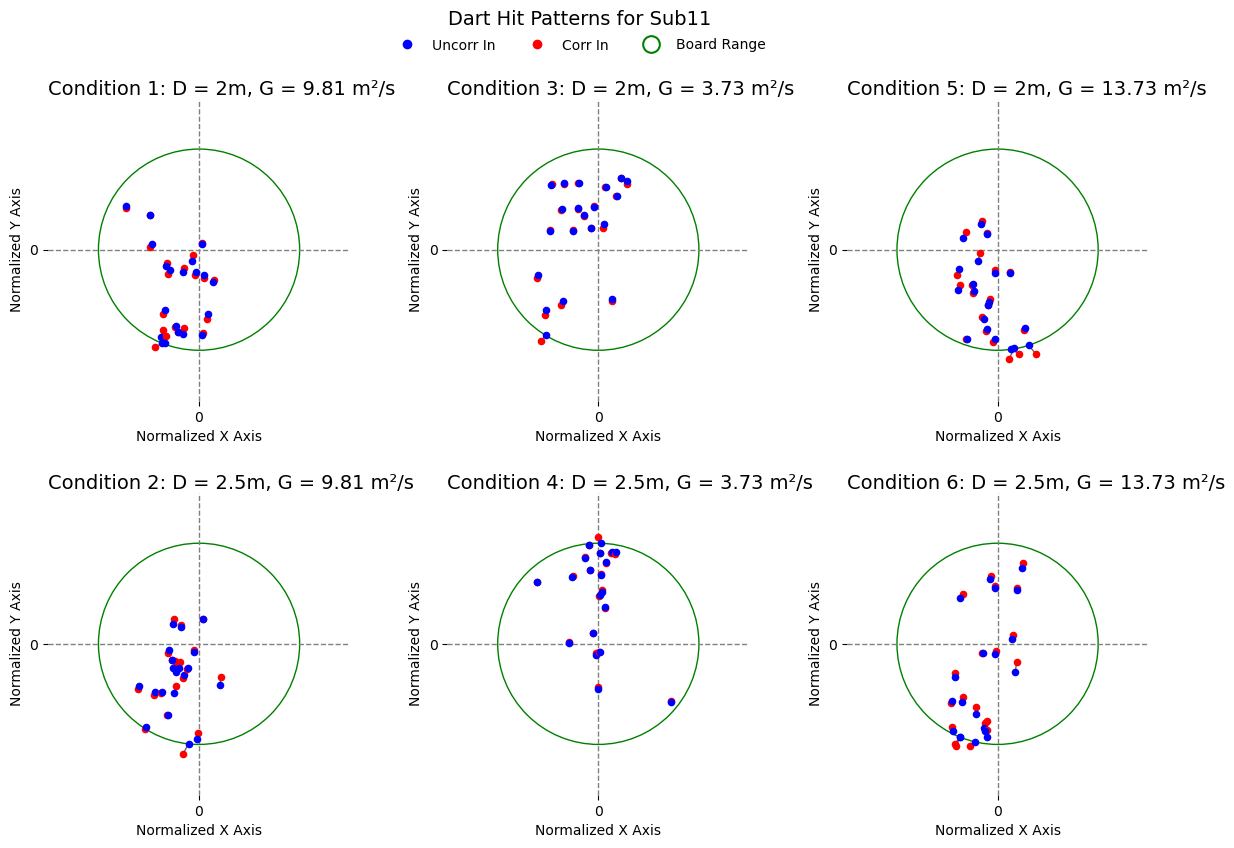

In [ ]:
TARGETRADIUS = current_phase.board_radius

for sub_num in sub_nums:
    file_paths = list(current_phase.data_dir.glob(f"{sub_num}_all_*.csv"))
    if file_paths:
        df = pd.read_csv(file_paths[0])

    min_out_dist, max_in_dist = df.loc[df["HitObjectTag"]=="Floor", "HitDistanceCorr"].min()/TARGETRADIUS, df.loc[df["HitObjectTag"]=="Target", "HitDistanceCorr"].max()/TARGETRADIUS
    # print(min_out_dist, max_in_dist)

    def scale_row(row):
        marker = row["HitObjectTag"]
        dist = row["HitDistanceCorr"]
        x, y, z = row["HitRelativeCorrX"], row["HitRelativeCorrY"], row["HitRelativeCorrZ"]
        xo, yo, zo = row["HitRelativeX"], row["HitRelativeY"], row["HitRelativeZ"]

        if marker == "Target":
            scale = 1 / TARGETRADIUS
        else:
            C = 1.0
            r_new = np.log(dist / TARGETRADIUS) + C
            scale = r_new / dist
            # scale = 1 / TARGETRADIUS

        return pd.Series([x * scale, y * scale, z * scale, xo * scale, yo * scale, zo * scale, dist * scale],
                        index=["HitRelativeCorrX", "HitRelativeCorrY", "HitRelativeCorrZ", "HitRelativeX", "HitRelativeY", "HitRelativeZ","HitRelativeDistance"])

    df[["HitRelativeCorrX", "HitRelativeCorrY", "HitRelativeCorrZ", "HitRelativeX", "HitRelativeY", "HitRelativeZ","HitRelativeDistance"]] = df.apply(scale_row, axis=1)
    title_name = f"Dart Hit Patterns for Sub{sub_num}"
    location_error_comparsion_plotter(df, title_name)

## 4. Timestamp Jittering

This section examines the distribution of frame time differences between the nominal sampling rate and the actual sampling rate to evaluate potential timestamp jitter in the recorded data.

—— hand ————
Mean:    15.8277
Median:  12.0000
Max:     66.0000
Min:     4.0000
Std:     6.4639
IQR:     11.0000
Outlier ratio: 0.31%  (173/56513)

—— finger ————
Mean:    9.3106
Median:  8.3325
Max:     2540.3816
Min:     3.2832
Std:     13.0776
IQR:     0.9756
Outlier ratio: 6.33%  (6083/96078)

—— eeg ————
Mean:    3.9971
Median:  0.0808
Max:     496.8289
Min:     0.0339
Std:     39.7268
IQR:     0.1006
Outlier ratio: 6.99%  (15622/223613)

—— emg ————
Mean:    4.0138
Median:  0.0759
Max:     485.0715
Min:     0.0337
Std:     38.7409
IQR:     0.0823
Outlier ratio: 8.05%  (17957/223056)

—— eye ————
Mean:    5.0020
Median:  5.0000
Max:     10.0154
Min:     3.9404
Std:     0.0577
IQR:     0.0071
Outlier ratio: 10.70%  (19132/178845)



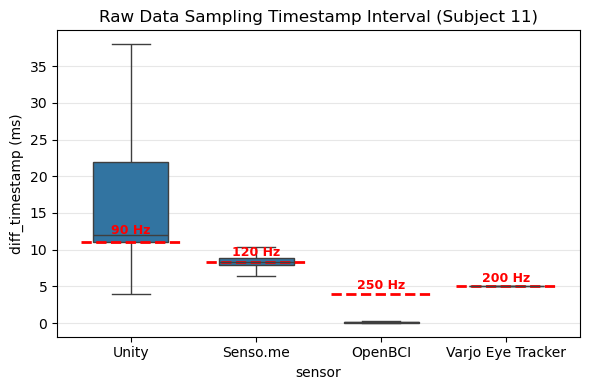

In [17]:
base = base_dir / "1_chopped"

declared_freqs = {
    "hand": 90,
    "finger": 120,
    "eeg": 250,
    "emg": 250,
    "eye": 200
}

declared_intervals = {k: 1000 / v for k, v in declared_freqs.items()}

for sub in sub_nums:
    all_hand = []
    all_finger = []
    all_eye = []
    all_eeg = []
    all_emg = []

    for sub_dir in sorted(base.glob(f"sub{sub}_*")):
        for f in sorted(sub_dir.glob("hand_position_order*_cond*.csv")):
            # corresponding marker file (same order/cond encoded in name)
            hand_name = f.name.replace("hand_position_", "hmd_")
            hand_path = f.parent / hand_name

            eye_name = f.name.replace("hand_position_", "eye_")
            eye_path = f.parent / eye_name

            eeg_name = f.name.replace("hand_position_", "eeg_")
            eeg_path = f.parent / eeg_name

            emg_name = f.name.replace("hand_position_", "emg_")
            emg_path = f.parent / emg_name

            # read files
            df_hand = pd.read_csv(hand_path,usecols=["UnixTime(ms)"]).rename(columns={"UnixTime(ms)": "timestamp"})
            df_eye = pd.read_csv(eye_path,usecols=["Capture Unix timestamp"]).rename(columns={"Capture Unix timestamp": "timestamp"})
            df_eeg = pd.read_csv(eeg_path,usecols=["Raw Timestamp(ms)"]).rename(columns={"Raw Timestamp(ms)": "timestamp"})
            df_finger = pd.read_csv(f,usecols=["unix_time"]).rename(columns={"unix_time": "timestamp"})
            df_emg = pd.read_csv(emg_path,usecols=["Raw Timestamp(ms)"]).rename(columns={"Raw Timestamp(ms)": "timestamp"})

            df_finger["timestamp"] = df_finger["timestamp"] / 1e6
            df_eye["timestamp"] = df_eye["timestamp"] / 1e6
            
            # diff
            def add_diff_and_deviation(df, sensor_name, declared_intervals):
                df = df.assign(
                    diff_timestamp = df["timestamp"].diff(),
                    deviation_from_declared = lambda d: d["timestamp"].diff() - declared_intervals[sensor_name]
                ).dropna(subset=["deviation_from_declared"])
                
                mean = df["deviation_from_declared"].mean()
                std = df["deviation_from_declared"].std()
                df["zscore"] = (df["deviation_from_declared"] - mean) / std

                return df
            
            df_hand = add_diff_and_deviation(df_hand, "hand", declared_intervals)
            df_finger = add_diff_and_deviation(df_finger, "finger", declared_intervals)
            df_eeg = add_diff_and_deviation(df_eeg, "eeg", declared_intervals)
            df_emg = add_diff_and_deviation(df_emg, "emg", declared_intervals)
            df_eye = add_diff_and_deviation(df_eye, "eye", declared_intervals)

            # append
            all_hand.append(df_hand)
            all_finger.append(df_finger)
            all_eeg.append(df_eeg)
            all_emg.append(df_emg)
            all_eye.append(df_eye)

    # concat
    hand_df = pd.concat(all_hand, ignore_index=True)
    finger_df = pd.concat(all_finger, ignore_index=True)
    eeg_df = pd.concat(all_eeg, ignore_index=True)
    emg_df = pd.concat(all_emg, ignore_index=True)
    eye_df = pd.concat(all_eye, ignore_index=True)
    
    def stats_reporter(df, col, name="df"):
        data = df[col].dropna()
        q1 = data.quantile(0.25)
        q3 = data.quantile(0.75)
        iqr = q3 - q1

        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        outliers = data[(data < lower_bound) | (data > upper_bound)]
        outlier_ratio = len(outliers) / len(data) * 100  # %

        print(f"—— {name} ————")
        print(f"Mean:    {data.mean():.4f}")
        print(f"Median:  {data.median():.4f}")
        print(f"Max:     {data.max():.4f}")
        print(f"Min:     {data.min():.4f}")
        print(f"Std:     {data.std():.4f}")
        print(f"IQR:     {iqr:.4f}")
        print(f"Outlier ratio: {outlier_ratio:.2f}%  ({len(outliers)}/{len(data)})")
        print()

    # report stats
    df_list = [
        (hand_df, "hand"),
        (finger_df, "finger"),
        (eeg_df, "eeg"),
        (emg_df, "emg"),
        (eye_df, "eye"),
    ]

    for df, name in df_list:
        stats_reporter(df, "diff_timestamp", name=name)

    # draw hist
    plt.figure(figsize=(6, 4))

    combined = pd.concat([
        hand_df.assign(sensor="Unity"),
        finger_df.assign(sensor="Senso.me"),
        eeg_df.assign(sensor="OpenBCI"),
        # emg_df.assign(sensor="emg"),
        eye_df.assign(sensor="Varjo Eye Tracker")
    ])
    sns.boxplot(data=combined, x="sensor", y="diff_timestamp", showfliers=False, width=0.6)
    # sns.violinplot(data=combined, x="sensor", y="deviation_from_declared", width=0.6)

    lag = 0
    for i, sensor in enumerate(declared_intervals.keys()):
        if sensor == "emg":
            lag = -1
            continue
        interval = declared_intervals[sensor]
        plt.hlines(interval, i + lag - 0.4, i + lag + 0.4, color="red", linestyles="--", linewidth=2)
        plt.text(
            i + lag, interval * 1.05, f"{declared_freqs[sensor]} Hz",
            color="red", ha="center", va="bottom", fontsize=9, fontweight="bold"
        )

    plt.title(f"Raw Data Sampling Timestamp Interval (Subject {sub})")
    plt.ylabel("diff_timestamp (ms)")
    # plt.yscale("symlog", linthresh=0.1) 
    # plt.ylim(-10,25)
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

## 2. Error correction and learning analysis
### 2.1 Error distribution

In [ ]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

threshold = 0.256

def location_error_plotter(df, title):
    all_x = df["HitRelativeCorrX"].tolist()
    all_y = df["HitRelativeCorrY"].tolist()
    conditions = condition_mapping.CONDITION_MAPPING.condition_sort(df,current_phase.cond_order)
    
    x_max_abs = max(abs(min(all_x)), abs(max(all_x))) + 1.0
    x_min, x_max = -x_max_abs, x_max_abs
    y_min, y_max = min(all_y) - 1.0, max(all_y) + 1.0
    x_y_ratio = np.abs(x_max - x_min) / np.abs(y_max - y_min)

    rows, cols = 2, 3
    fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 8*rows))
    axes = axes.flatten()

    # ===== histogram ======
    all_counts_x, all_counts_y = [], []
    bin_width = 0.15

    for cond in conditions:
        group = df[df["Condition"] == cond].reset_index(drop=True)
        xs = group["HitRelativeCorrX"].values
        ys = group["HitRelativeCorrY"].values
        
        bins_x = np.arange(x_min, x_max + bin_width, bin_width)
        bins_y = np.arange(y_min, y_max + bin_width, bin_width)

        counts_x, _ = np.histogram(xs, bins=bins_x)
        counts_y, _ = np.histogram(ys, bins=bins_y)
        
        all_counts_x.append(counts_x.max())
        all_counts_y.append(counts_y.max())

    max_count_x = max(all_counts_x)
    max_count_y = max(all_counts_y)
    x_y_count_ratio = max_count_x/max_count_y
    overall_max_count = max(max_count_x,max_count_y)

    for idx, cond in enumerate(conditions):
        ax_scatter = axes[idx]
        # ax_scatter.set_title(f"Condition {cond}\nD = {condition_dict[cond][2]}m, G = {round(condition_dict[cond][-1]*9.81,2)}m^2/s", x=0, y=1.1, ha="left", fontsize=14)
        ax_scatter.text(
            0, 1.15, f"Condition {cond}",
            transform=ax_scatter.transAxes,
            ha="left", va="bottom", fontsize=14
        )

        ax_scatter.text(
            0, 1.12, f"D = {condition_dict[cond][2]}m, G = {round(condition_dict[cond][-1]*9.81, 2)} m²/s",
            transform=ax_scatter.transAxes,
            ha="left", va="bottom", fontsize=10, color="black"
        )

        group = df[df["Condition"] == cond].reset_index(drop=True)
        coords = [
            (row["HitRelativeCorrX"], row["HitRelativeCorrY"],
            "in" if row["HitObjectTag"] == "Target" else "out")
            for _, row in group.iterrows()
        ]
        if not coords:
            continue
        xs, ys, labels = zip(*coords)

        # ===== scatter =====
        ax_scatter.plot(xs, ys, linestyle="-", color="black", linewidth=1, alpha=0.6)
        for i, (x, y, lbl) in enumerate(coords, start=1):
            color = "blue" if lbl == "in" else "red"
            marker = 'o' if lbl == "in" else "x"
            ax_scatter.scatter(x, y, color=color, marker=marker, s=20, zorder=3)
        ax_scatter.add_patch(plt.Circle((0, 0), 1, color="g", fill=False))
        ax_scatter.axhline(0, color="gray", linestyle="--", lw=1)
        ax_scatter.axvline(0, color="gray", linestyle="--", lw=1)
        ax_scatter.set_aspect("equal", adjustable="box")
        ax_scatter.set_xlabel("Normalized X Axis")
        ax_scatter.set_ylabel("Normalized Y Axis")
        ax_scatter.set_xlim(x_min, x_max)
        ax_scatter.set_ylim(y_min, y_max)
        # ax_scatter.set_title(f"Condition {cond}", fontsize=10)

        for spine in ax_scatter.spines.values():
            spine.set_visible(False)
        ax_scatter.set_xticks([0])
        ax_scatter.set_yticks([0])

        # ===== X histogram =====
        bins = np.arange(x_min, x_max + bin_width, bin_width)
        ax_histx = inset_axes(ax_scatter, width="100%", height="50%", 
                            loc="lower center", bbox_to_anchor=(0,1,1,0.2),
                            bbox_transform=ax_scatter.transAxes, borderpad=0)
        ax_histx.hist(xs, bins=bins_x, color="#939393", edgecolor="black")
        ax_histx.set_xlim(ax_scatter.get_xlim())
        ax_histx.set_ylim(0, overall_max_count)
        ax_histx.set_ylabel("count")
        ax_histx.spines["top"].set_visible(False)
        ax_histx.spines["right"].set_visible(False)
        # ax_histx.axis("off")

        # ===== Y histogram =====
        bins = np.arange(y_min, y_max + bin_width, bin_width)
        ax_histy = inset_axes(ax_scatter, width="50%", height="100%", 
                            loc="center left", bbox_to_anchor=(1,0,(0.2/(x_y_ratio)),1),
                            bbox_transform=ax_scatter.transAxes, borderpad=0)
        ax_histy.hist(ys, bins=bins_y, orientation="horizontal", color="#939393", edgecolor="black")
        ax_histy.set_ylim(ax_scatter.get_ylim())
        ax_histy.set_xlim(0, overall_max_count)
        ax_histy.set_xlabel("count")
        ax_histy.spines["top"].set_visible(False)
        ax_histy.spines["right"].set_visible(False)
        # ax_histy.axis("off")

    for j in range(len(conditions), len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle(title, fontsize=14, y=1)
    handles = [
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', linestyle="None", markersize=8, label='Hit Point on the Target'),
        plt.Line2D([0], [0], marker='x', color='red', markerfacecolor='w', linestyle="None", markersize=8, mew=1.5, label='Hit Point out the Target'),
        plt.Line2D([0], [0], marker='o', color='green', markerfacecolor='w', linestyle="None", markersize=12, mew=1.5, label='Target'),
    ]
    fig.legend(handles=handles, loc="upper center", ncol=6, fontsize=10, frameon=False, bbox_to_anchor=(0.5, 0.99))
    plt.tight_layout(pad=2, w_pad=2, h_pad=4)
    # plt.tight_layout()
    plt.show()


1.1282593880106433 1.1081594397879322


/var/folders/ld/ydrxs2j90nx98nz_s4zpd5l80000gn/T/ipykernel_6027/3603588751.py:124: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=2, w_pad=2, h_pad=4)


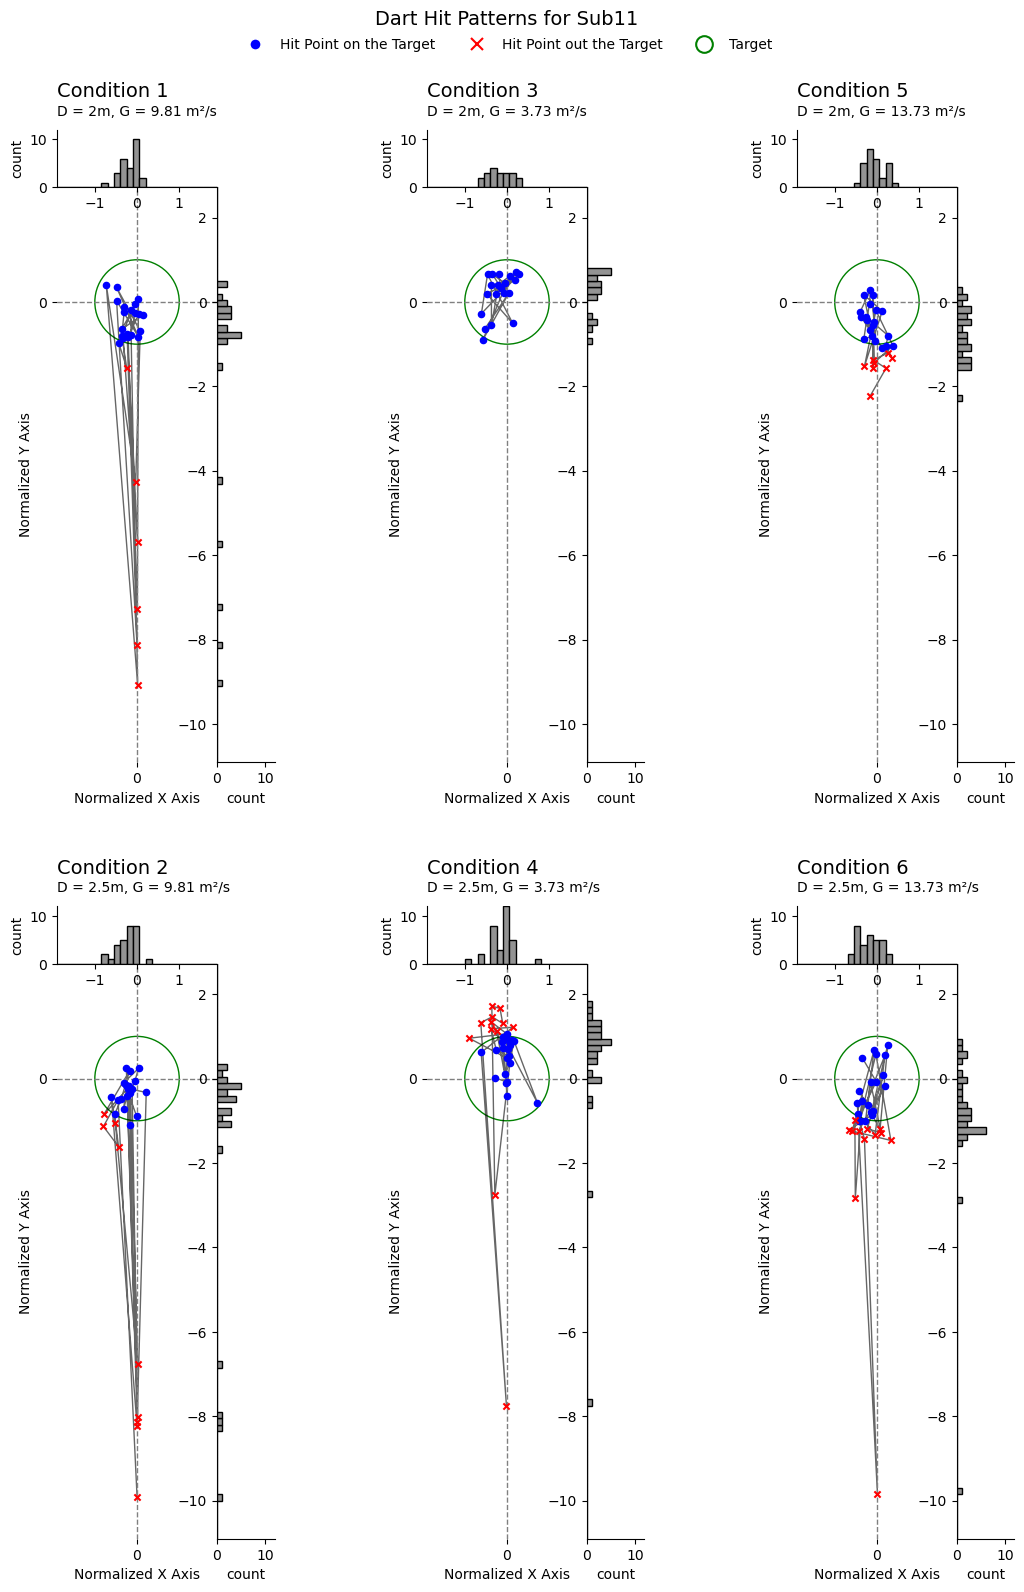

In [ ]:
TARGETRADIUS = 0.5117/2

for sub_num in sub_nums:
    file_paths = list(current_phase.data_dir.glob(f"{sub_num}_all_*.csv"))
    if file_paths:
        df = pd.read_csv(file_paths[0])

    min_out_dist, max_in_dist = df.loc[df["HitObjectTag"]=="Floor", "HitDistanceCorr"].min()/TARGETRADIUS, df.loc[df["HitObjectTag"]=="Target", "HitDistanceCorr"].max()/TARGETRADIUS
    print(min_out_dist, max_in_dist)

    def scale_row(row):
        marker = row["HitObjectTag"]
        dist = row["HitDistanceCorr"]
        x, y, z = row["HitRelativeCorrX"], row["HitRelativeCorrY"], row["HitRelativeCorrZ"]

        if marker == "Target":
            scale = 1 / TARGETRADIUS
        else:
            C = 1.0
            r_new = np.log(dist / TARGETRADIUS) + C
            scale = r_new / dist
            # scale = 1 / TARGETRADIUS

        return pd.Series([x * scale, y * scale, z * scale, dist * scale],
                        index=["HitRelativeCorrX", "HitRelativeCorrY", "HitRelativeCorrZ", "HitRelativeDistance"])

    df[["HitRelativeCorrX", "HitRelativeCorrY", "HitRelativeCorrZ","HitRelativeDistance"]] = df.apply(scale_row, axis=1)
    title_name = f"Dart Hit Patterns for Sub{sub_num}"
    location_error_plotter(df, title_name)

### 2.2 Error correction and learning

In [19]:
# conditions = sorted(df["Condition"].unique())

def trial_error_plotter(df, title):
    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    axes = axes.flatten()

    x_max = df.groupby("Condition").size().max()
    y_min, y_max = df["HitRelativeDistance"].min(), df["HitRelativeDistance"].max()

    for idx, cond in enumerate(current_phase.cond_order):
        ax = axes[idx]
        group = df[df["Condition"] == cond].reset_index(drop=True)
        group["order"] = np.arange(1, len(group) + 1)

        in_points = group[group["HitObjectTag"] == "Target"]
        out_points = group[group["HitObjectTag"] != "Target"]

        ax.scatter(in_points["order"], in_points["HitRelativeDistance"], 
                marker="o", color="blue", label="in", alpha=0.7)
        ax.scatter(out_points["order"], out_points["HitRelativeDistance"], 
                marker="x",color="red", label="out", alpha=0.7)

        ax.axhline(1, color="black", linestyle="--", linewidth=1)

        x_all = group["order"].values
        y_all = group["HitRelativeDistance"].values

        if len(group) > 3:
            X = np.column_stack((x_all**2, x_all, np.ones_like(x_all)))
            model = sm.OLS(y_all, X).fit()

            x_fit = np.linspace(x_all.min(), x_all.max(), 200)
            X_fit = np.column_stack((x_fit**2, x_fit, np.ones_like(x_fit)))
            y_fit = model.predict(X_fit)

            pred = model.get_prediction(X_fit)
            pred_ci = pred.conf_int(alpha=0.05)

            ax.plot(x_fit, y_fit, color="green", linewidth=2, label="fit")
            ax.fill_between(x_fit, pred_ci[:, 0], pred_ci[:, 1],
                            color="green", alpha=0.2)
        
        if len(in_points) > 3:
            x = in_points["order"].values
            y = in_points["HitRelativeDistance"].values

            X = np.column_stack((x**2, x, np.ones_like(x)))
            model = sm.OLS(y, X).fit()

            x_fit = np.linspace(x_all.min(), x_all.max(), 200)
            X_fit = np.column_stack((x_fit**2, x_fit, np.ones_like(x_fit)))
            y_fit = model.predict(X_fit)

            pred = model.get_prediction(X_fit)
            pred_ci = pred.conf_int(alpha=0.05)

            ax.plot(x_fit, y_fit, color="blue", linewidth=2, label="fit (in only)")
            ax.fill_between(x_fit, pred_ci[:, 0], pred_ci[:, 1],
                            color="blue", alpha=0.2)

        ax.set_title(f"Condition {cond}\nD = {condition_dict[cond][2]}m, G = {round(condition_dict[cond][-1]*9.81,2)}m²/s", ha="left", x=0, fontsize=12)
        ax.set_xlabel("Trial order")
        ax.set_ylabel("Hit Relative Distance")
        ax.set_xlim(0, x_max + 1)
        ax.set_ylim(y_min-0.5, y_max+0.5)
        # ax.legend(loc="lower left", bbox_to_anchor=(1.02, 0.0), borderaxespad=0, frameon=False)

    fig.suptitle(title, fontsize=14, y=1)
    handles = [
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', linestyle="None", markersize=8, label='Hit Point on the Target'),
        plt.Line2D([0], [0], marker='x', color='red', markerfacecolor='w', linestyle="None", markersize=8, mew=1.5, label='Hit Point out the Target'),
        plt.Line2D([0], [0], color="green", lw=2, label="All Points Fit Curve", linestyle="-"),
        plt.Line2D([0], [0], color="blue", lw=2, label="Target Hit Points Fit Curve", linestyle="-"),
    ]
    fig.legend(handles=handles, loc="upper center", ncol=4, fontsize=10, frameon=False, bbox_to_anchor=(0.5, 0.99))
    plt.tight_layout()
    plt.show()

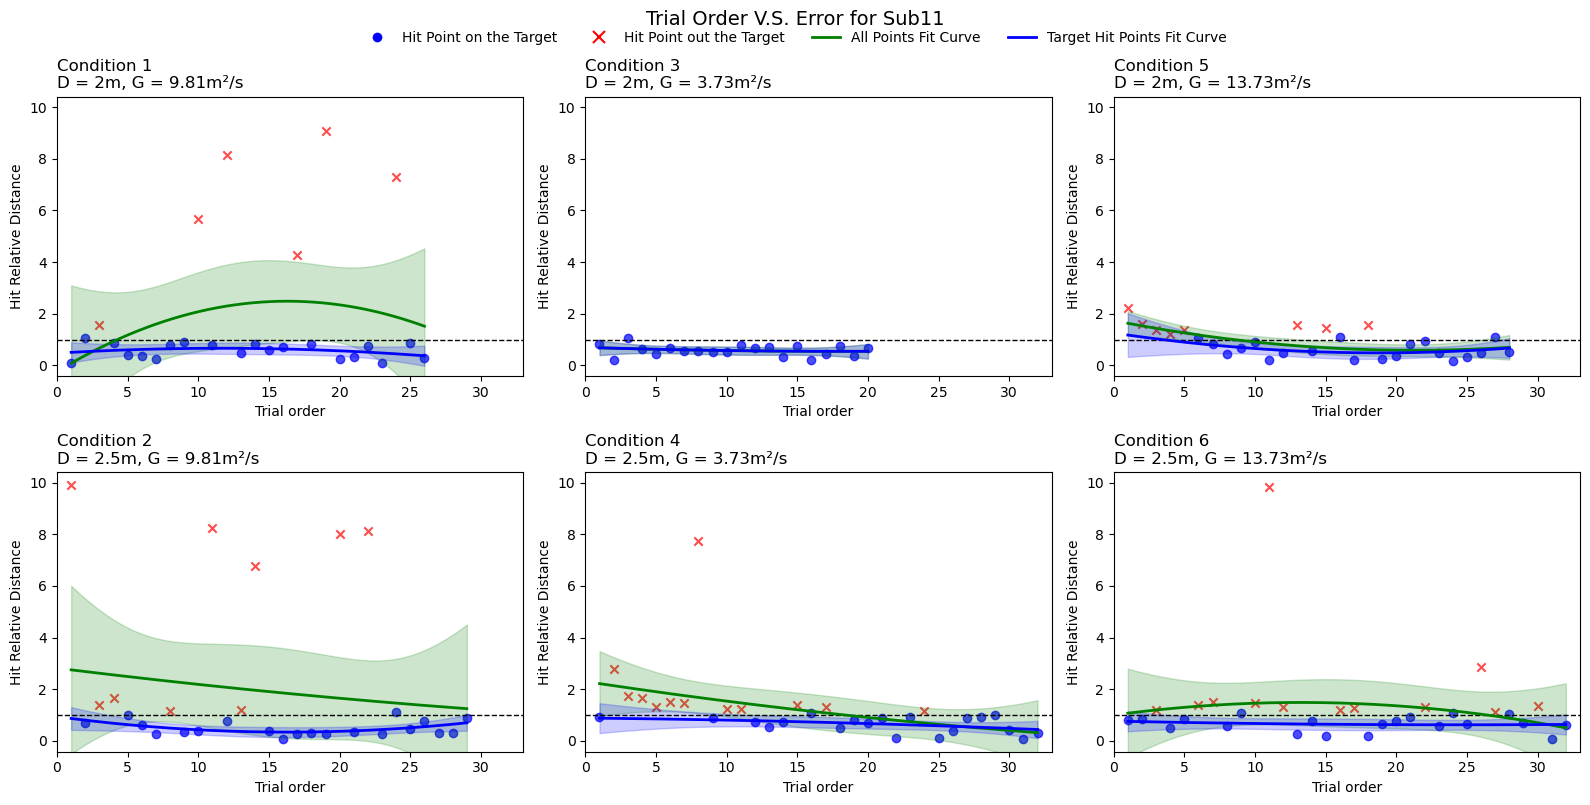

In [20]:
for sub_num in sub_nums:
    file_paths = list(base_dir.glob(f"{sub_num}_all_*.csv"))
    if file_paths:
        df = pd.read_csv(file_paths[0])

    TARGETRADIUS = current_phase.board_radius

    def scale_row(row):
        marker = row["HitObjectTag"]
        dist = row["HitDistanceCorr"]
        x, y, z = row["HitRelativeX"], row["HitRelativeY"], row["HitRelativeZ"]

        scale = 1 / TARGETRADIUS

        if marker == "Target":
            scale = 1 / TARGETRADIUS
        else:
            C = 1.0
            r_new = np.log(dist / TARGETRADIUS) + C
            scale = r_new / dist
            # scale = 1 / TARGETRADIUS

        return pd.Series([x * scale, y * scale, z * scale, dist * scale],
                        index=["HitRelativeX", "HitRelativeY", "HitRelativeZ", "HitRelativeDistance"])

    df[["HitRelativeX", "HitRelativeY", "HitRelativeZ","HitRelativeDistance"]] = df.apply(scale_row, axis=1)
    title_name = f"Trial Order V.S. Error for Sub{sub_num}"
    trial_error_plotter(df, title_name)

# 3. Time-series data visualization

### Prepare Display Time Start for Each Participate
### [IMPORTANT] Be sure to run this block before going forward to visualize each modality

In [9]:
base = base_dir / "1_chopped"
OW_STARTS = {}

for sub in sub_nums:
    all_markers = []
    sub_ow_starts = {}

    for sub_dir in sorted(base.glob(f"sub{sub}_*")):
        for f in sorted(sub_dir.glob("marker_order*_cond*.csv")):
            mk = pd.read_csv(f, usecols=["UnixTime(ms)", "Marker", "Condition"]).copy()
            t0 = mk["UnixTime(ms)"].iloc[0]
            mk["t_rel_s"] = (mk["UnixTime(ms)"] - t0) / 1000.0
            all_markers.append(mk)

    for cond in current_phase.cond_order:
        mk = None
        if all_markers:
            mk = pd.concat(
                [m for m in all_markers if m["Condition"].iloc[0] == cond],
                ignore_index=True
            ) if any(m["Condition"].iloc[0] == cond for m in all_markers) else None

        if mk is not None and not mk.empty:
            mk_pinch = mk.loc[mk["Marker"] == "Pinched"].copy().reset_index(drop=True)
            num_pinch_mk = len(mk_pinch)
            if num_pinch_mk >= 5:
                start_pinch_ind = random.randint(0, num_pinch_mk - 5)
                OW_START = int(mk_pinch["t_rel_s"].iloc[start_pinch_ind]) - 0.5
                if OW_START <= 0:
                    OW_START = 0
                sub_ow_starts[cond] = OW_START
            else:
                sub_ow_starts[cond] = None
        else:
            sub_ow_starts[cond] = None

    OW_STARTS[sub] = sub_ow_starts

print("OW_STARTS:", OW_STARTS)

OW_STARTS: {11: {1: 7.5, 3: 41.5, 5: 79.5, 2: 180.5, 4: 38.5, 6: 120.5}}


## 3.1 Dart

In [64]:
# Visualize dart position (X, Y, Z) by condition over time
# configurations
base = current_phase.data_dir / "1_chopped"

# Global color dictionary
colorDictionary = {
    "X": "#00ff00",  # green
    "Y": "#0095ff",  # blue
    "Z": "#ff0000",  # red
}

DISPLAYTIME = float(10)
DARTLINEWIDTH = 2.0
HANDLINEWIDTH = 1.5

# Max pooling of the raw velocity signal (kernel=5 frames)
interest_variable = "MaxPoolingVelocity"
# values directly read from Unity after throwing, without collision correction or physics-based velocity estimation
dart_velocity_after_throwing = "DartSimulatedVelocity"

In [ ]:
def dart_plotter(ow_starts, all_dart, all_hand, all_markers, title):
    legend_items = {
        "X": colorDictionary["X"],
        "Y": colorDictionary["Y"],
        "Z": colorDictionary["Z"]
    }

    dart_df = pd.concat(all_dart, ignore_index=True)
    hand_df = pd.concat(all_hand, ignore_index=True)
    order = [1, 3, 5, 2, 4, 6]
    valid_conditions = dart_df.loc[dart_df["Condition"] != 0, "Condition"].dropna().unique()
    conditions = sorted(valid_conditions, key=lambda x: order.index(x))
    y_min, y_max = -7, 10

    # one subplot per condition; each subplot has X, Y, Z as lines
    n = len(conditions)
    rows, cols = (n + 1) // 3, 3
    fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 4*rows), sharex=False)
    axes = axes.flatten()
    fig.suptitle(title, fontsize=16, y=1.07)
    handles = [
        plt.Line2D([0], [0], color=colorDictionary["X"], lw=2, label="Dart X", linestyle="-"),
        plt.Line2D([0], [0], color=colorDictionary["Y"], lw=2, label="Dart Y", linestyle="-"),
        plt.Line2D([0], [0], color=colorDictionary["Z"], lw=2, label="Dart Z", linestyle="-"),
        plt.Line2D([0], [0], color=colorDictionary["X"], lw=2, label="Hand X", linestyle="--"),
        plt.Line2D([0], [0], color=colorDictionary["Y"], lw=2, label="Hand Y", linestyle="--"),
        plt.Line2D([0], [0], color=colorDictionary["Z"], lw=2, label="Hand Z", linestyle="--"),
    ]
    fig.legend(handles=handles, loc="upper center", ncol=6, fontsize=12, frameon=False, bbox_to_anchor=(0.5, 1.05))

    for i, cond in enumerate(conditions):
        ax = axes[i]
        # ax.set_title(f"Condition {cond}\nD = {condition_dict[cond][2]}m, G = {round(condition_dict[cond][-1]*9.81,2)}m^2/s", x=0, y=1.25, ha="left", fontsize=14)
        fig.text(
            0, 1.40, f"Condition {cond}: D = {condition_dict[cond][2]}m, G = {round(condition_dict[cond][-1]*9.81, 2)} m²/s",
            transform=ax.transAxes,
            ha="left", va="bottom", fontsize=14
        )
        
        g = dart_df[dart_df["Condition"] == cond]
        h = hand_df[hand_df["Condition"] == cond]

        mk = None
        if all_markers:
            mk = pd.concat(
                [m for m in all_markers if m["Condition"].iloc[0] == cond],
                ignore_index=True
            ) if any(m["Condition"].iloc[0] == cond for m in all_markers) else None

        if mk is not None and not mk.empty:
            # random pick start point of observation window
            OW_START = ow_starts[cond]
            OW_END = OW_START + DISPLAYTIME
            if OW_END > mk["t_rel_s"].iloc[-1]:
                OW_END = mk["t_rel_s"].iloc[-1]
            
            # get hand and dart df in observation window
            g = g.loc[(g["t_rel_s"] <= OW_END) & (g["t_rel_s"] >= OW_START)]
            h = h.loc[(h["t_rel_s"] <= OW_END) & (h["t_rel_s"] >= OW_START)]

            mk["Marker"] = mk["Marker"].replace({
                "Low Destroyed": "Destroyed",
                "High Destroyed": "Destroyed"
            })

            mk = mk[mk["Marker"].isin(["Pinched", "Released", "Destroyed", "Hit"])]
            
            mk = mk.sort_values("t_rel_s")

            use_rigid = False
            last_t = OW_START

            for _, row in mk.loc[(mk["t_rel_s"] <= OW_END) & (mk["t_rel_s"] >= OW_START)].iterrows():
                t = row["t_rel_s"]
                label = row["Marker"]

                ax.text(
                    t, 1.02, label,
                    transform=ax.get_xaxis_transform(),
                    rotation=90, ha="center", va="bottom",
                    fontsize=12, color="#444444",
                    clip_on=False
                )

                seg = g[(g["t_rel_s"] >= last_t) & (g["t_rel_s"] <= t)]
                seg_h = h[(h["t_rel_s"] >= last_t) & (h["t_rel_s"] <= t)]

                if not seg.empty:
                    if use_rigid:
                        ax.plot(seg["t_rel_s"], seg[f"{dart_velocity_after_throwing}_X"], color=colorDictionary["X"], linewidth=DARTLINEWIDTH, alpha=0.9, zorder=3)
                        ax.plot(seg["t_rel_s"], seg[f"{dart_velocity_after_throwing}_Y"], color=colorDictionary["Y"], linewidth=DARTLINEWIDTH, alpha=0.9, zorder=3)
                        ax.plot(seg["t_rel_s"], seg[f"{dart_velocity_after_throwing}_Z"], color=colorDictionary["Z"], linewidth=DARTLINEWIDTH, alpha=0.9, zorder=3)
                        ax.plot(seg["t_rel_s"], seg["DartNaiveVelocityX"], color=colorDictionary["X"], linestyle= ":", linewidth=DARTLINEWIDTH, alpha=0.3, zorder=2)
                        ax.plot(seg["t_rel_s"], seg["DartNaiveVelocityY"], color=colorDictionary["Y"], linestyle= ":", linewidth=DARTLINEWIDTH, alpha=0.3, zorder=2)
                        ax.plot(seg["t_rel_s"], seg["DartNaiveVelocityZ"], color=colorDictionary["Z"], linestyle= ":", linewidth=DARTLINEWIDTH, alpha=0.3, zorder=2)
                    else:
                        ax.plot(seg["t_rel_s"], seg[f"{interest_variable}_X"], color=colorDictionary["X"], linewidth=DARTLINEWIDTH, alpha=0.9, zorder=3)
                        ax.plot(seg["t_rel_s"], seg[f"{interest_variable}_Y"], color=colorDictionary["Y"], linewidth=DARTLINEWIDTH, alpha=0.9, zorder=3)
                        ax.plot(seg["t_rel_s"], seg[f"{interest_variable}_Z"], color=colorDictionary["Z"], linewidth=DARTLINEWIDTH, alpha=0.9, zorder=3)

                if label == "Released":
                    use_rigid = True
                elif label == "Pinched":
                    use_rigid = False

                ax.axvline(t, color="#888888", linestyle="-", linewidth=1, alpha=0.6)

                last_t = t

            seg = g[(g["t_rel_s"] >= last_t) & (g["t_rel_s"] <= OW_END)]
            if not seg.empty:
                if use_rigid:
                    ax.plot(seg["t_rel_s"], seg["DartNaiveVelocityX"], color=colorDictionary["X"], linewidth=DARTLINEWIDTH, alpha=0.9, zorder=3)
                    ax.plot(seg["t_rel_s"], seg["DartNaiveVelocityY"], color=colorDictionary["Y"], linewidth=DARTLINEWIDTH, alpha=0.9, zorder=3)
                    ax.plot(seg["t_rel_s"], seg["DartNaiveVelocityZ"], color=colorDictionary["Z"], linewidth=DARTLINEWIDTH, alpha=0.9, zorder=3)
                else:
                    ax.plot(seg["t_rel_s"], seg[f"{interest_variable}_X"], color=colorDictionary["X"], linewidth=DARTLINEWIDTH, alpha=0.9, zorder=3)
                    ax.plot(seg["t_rel_s"], seg[f"{interest_variable}_Y"], color=colorDictionary["Y"], linewidth=DARTLINEWIDTH, alpha=0.9, zorder=3)
                    ax.plot(seg["t_rel_s"], seg[f"{interest_variable}_Z"], color=colorDictionary["Z"], linewidth=DARTLINEWIDTH, alpha=0.9, zorder=3)

        else:
            ax.plot(g["t_rel_s"], g[f"{interest_variable}_X"], color=colorDictionary["X"], alpha=0.9, zorder=3)
            ax.plot(g["t_rel_s"], g[f"{interest_variable}_Y"], color=colorDictionary["Y"], alpha=0.9, zorder=3)
            ax.plot(g["t_rel_s"], g[f"{interest_variable}_Z"], color=colorDictionary["Z"], alpha=0.9, zorder=3)

        ax.plot(h["t_rel_s"], h["HandNaiveVelocity_X"], color=colorDictionary["X"], linestyle= "--", linewidth=HANDLINEWIDTH, alpha=0.75, zorder=2)
        ax.plot(h["t_rel_s"], h["HandNaiveVelocity_Y"], color=colorDictionary["Y"], linestyle= "--", linewidth=HANDLINEWIDTH, alpha=0.75, zorder=2)
        ax.plot(h["t_rel_s"], h["HandNaiveVelocity_Z"], color=colorDictionary["Z"], linestyle= "--", linewidth=HANDLINEWIDTH, alpha=0.75, zorder=2)
        ax.axhspan(ymin=-0.1, ymax=6, color="lightblue", alpha=0.3)

        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Velocity (m/s)")

        ax.grid(False)
        ax.set_xlim(OW_START, OW_END)
        ax.set_xticks(np.arange(OW_START, OW_END+1, 1))
        ax.set_ylim(y_min, y_max)

    # remove any unused axes
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout(w_pad=5, h_pad=3)
    plt.show()

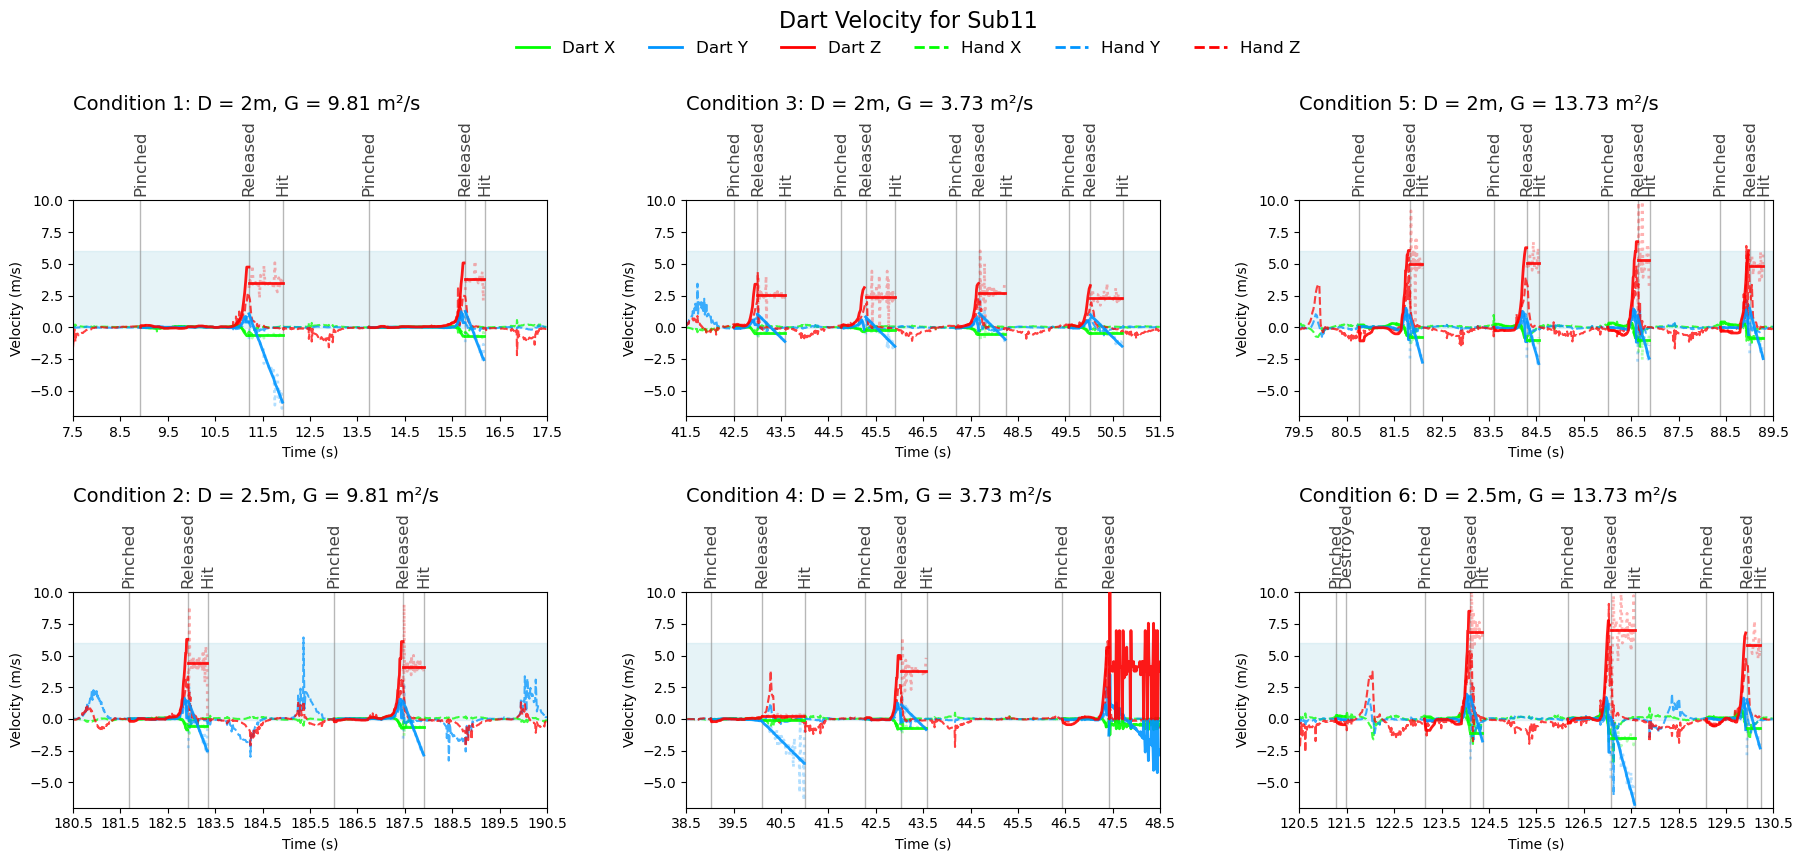

In [65]:
for sub in sub_nums:
    all_dart = []
    all_markers = []
    all_hand = []
    PINCH_STARTS = OW_STARTS[sub]

    for sub_dir in sorted(base.glob(f"sub{sub}_*")):
        for f in sorted(sub_dir.glob("dart_order*_cond*.csv")):
            df = pd.read_csv(f, usecols=[
                "UnixTime(ms)", "Condition",
                f"{interest_variable}_X", f"{interest_variable}_Y", f"{interest_variable}_Z",
                f"{dart_velocity_after_throwing}_X", f"{dart_velocity_after_throwing}_Y", f"{dart_velocity_after_throwing}_Z",
                "DartNaiveVelocityX", "DartNaiveVelocityY", "DartNaiveVelocityZ"
            ])

            # corresponding marker file (same order/cond encoded in name)
            marker_name = f.name.replace("dart_", "marker_")
            marker_path = f.parent / marker_name

            if marker_path.exists():
                mk = pd.read_csv(marker_path, usecols=["UnixTime(ms)", "Marker", "Condition"]).copy()
                t0 = mk["UnixTime(ms)"].iloc[0]
                mk["t_rel_s"] = (mk["UnixTime(ms)"] - t0) / 1000.0
                all_markers.append(mk)

            # normalize time per segment start
            df["t_rel_s"] = (df["UnixTime(ms)"] - t0) / 1000.0
            all_dart.append(df)
            
            # corresponding hmd file
            hmd_name = f.name.replace("dart_", "hmd_")
            hmd_path = f.parent / hmd_name

            df_hmd = pd.read_csv(hmd_path, usecols=[
                "UnixTime(ms)", "Condition",
                "HandNaiveVelocity_X", "HandNaiveVelocity_Y", "HandNaiveVelocity_Z"
            ])
            df_hmd["t_rel_s"] = (df_hmd["UnixTime(ms)"] - t0) / 1000.0
            all_hand.append(df_hmd)


    if not all_dart:
        raise RuntimeError(f"No chopped dart files found under {current_phase.data_dir}/1_chopped/")
    
    title_name = f"Dart Velocity for Sub{sub}"
    
    dart_plotter(PINCH_STARTS, all_dart, all_hand, all_markers, title_name)


## 3.2 EMG
### 3.2.1 Utils

In [ ]:
import scipy.signal
from scipy.signal import butter, cheby1, sosfilt, iirnotch, sosfreqz, sosfilt_zi, correlate, filtfilt, sosfiltfilt

def bandpass_with_notch(
    data, 
    lowcut, highcut, fs, 
    filter_type='butter', order=4, rp=0.1,
    notch_freqs=(60.0,120.0), Q=30.0
):

    nyq = 0.5 * fs
    low, high = lowcut / nyq, highcut / nyq
    if filter_type == 'butter':
        sos_band = butter(order, [low, high], btype='band', output='sos')
    elif filter_type == 'cheby1':
        sos_band = cheby1(order, rp, [low, high], btype='band', output='sos')
    else:
        raise ValueError("filter_type must be 'butter' or 'cheby1'")
    
    y = sosfiltfilt(sos_band, data)

    # ----- notch -----
    from scipy.signal import filtfilt
    for f0 in notch_freqs:
        b_notch, a_notch = iirnotch(w0=f0, Q=Q, fs=fs)
        y = filtfilt(b_notch, a_notch, y)

    return y

def emg_plotter(ow_starts, all_emg, all_markers, title, upoffset):
    emg_df = pd.concat(all_emg, ignore_index=True)
    conditions = condition_mapping.CONDITION_MAPPING.condition_sort(emg_df, current_phase.cond_order)

    # y_min, y_max = emg_df[["Ch1","Ch2","Ch3","Ch4","Ch5","Ch6","Ch7","Ch8"]].min().min(), emg_df[["Ch1","Ch2","Ch3","Ch4","Ch5","Ch6","Ch7","Ch8"]].max().max()
    y_min = -upoffset
    y_max = upoffset*8

    # one subplot per condition; each subplot has X, Y, Z as lines
    n = len(conditions)
    rows, cols = (n + 1) // 3, 3
    fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 4*rows), sharex=False)
    axes = axes.flatten()
    fig.suptitle(title, fontsize=16, y=1.01)

    for i, cond in enumerate(conditions):
        ax = axes[i]
        # ax.set_title(f"Condition {cond}\nD = {condition_dict[cond][2]}m, G = {round(condition_dict[cond][-1]*9.81,2)}m^2/s", x=0, y=1.25, ha="left", fontsize=14)
        fig.text(
            0, 1.40, f"Condition {cond}: D = {condition_dict[cond][2]}m, G = {round(condition_dict[cond][-1]*9.81, 2)} m²/s",
            transform=ax.transAxes,
            ha="left", va="bottom", fontsize=14
        )
        
        g = emg_df[emg_df["Condition"] == cond]

        mk = None
        if all_markers:
            mk = pd.concat(
                [m for m in all_markers if m["Condition"].iloc[0] == cond],
                ignore_index=True
            ) if any(m["Condition"].iloc[0] == cond for m in all_markers) else None

        if mk is not None and not mk.empty:
            OW_START = ow_starts[cond]
            OW_END = OW_START + DISPLAYTIME
            if OW_END > mk["t_rel_s"].iloc[-1]:
                OW_END = mk["t_rel_s"].iloc[-1]
            
            # get emg data inside OW
            g = g.loc[(g["t_rel_s"] <= OW_END) & (g["t_rel_s"] >= OW_START)]

            mk["Marker"] = mk["Marker"].replace({
                "Low Destroyed": "Destroyed",
                "High Destroyed": "Destroyed"
            })

            mk = mk[mk["Marker"].isin(["Pinched", "Released", "Destroyed", "Hit"])]
            mk = mk.sort_values("t_rel_s")

            for _, row in mk.loc[(mk["t_rel_s"] <= OW_END) & (mk["t_rel_s"] >= OW_START)].iterrows():
                t = row["t_rel_s"]
                label = row["Marker"]

                ax.text(
                    t, 1.02, label,
                    transform=ax.get_xaxis_transform(),
                    rotation=90, ha="center", va="bottom",
                    fontsize=12, color="#444444",
                    clip_on=False
                )

                ax.axvline(t, color="#888888", linestyle="-", linewidth=1, alpha=0.6)

        cmap = plt.get_cmap("tab10")

        for i in range(1, 9):
            ax.plot(
                g["t_rel_s"], g[f"Ch{i}"]+(i-1)*upoffset,
                color=cmap(i-1),
                label=f"Ch{i}",
                linewidth=1,
                zorder=2
            )
            ax.axhline((i-1)*upoffset, color="#888888", linestyle="-", linewidth=1, alpha=0.6)

        ax.spines['top'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.spines['right'].set_visible(False)

        ax.set_xlabel("Time(s)")

        # remove grid per request
        ax.grid(False)
        ax.set_xlim(OW_START, OW_END)
        ax.set_xticks(np.arange(OW_START, OW_END + 1.0, 1.0))
        ax.set_ylim(y_min, y_max)
        ax.set_yticks(np.arange(0, y_max, upoffset))
        ax.set_yticklabels(["Ch1","Ch2","Ch3","Ch4","Ch5","Ch6","Ch7","Ch8"])

    # remove any unused axes
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout(w_pad=5, h_pad=3)
    plt.show()

In [24]:
from scipy.signal import spectrogram

def emg_timefreq_plotter(ow_starts, all_emg, all_markers, title, fs=250, fmax=120):
    emg_df = pd.concat(all_emg, ignore_index=True)
    conditions = condition_mapping.CONDITION_MAPPING.condition_sort(emg_df, current_phase.cond_order)
    n = len(conditions)
    rows, cols = (n + 1) // 3, 3
    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 4 * rows), sharex=False)
    axes = axes.flatten()
    fig.suptitle(title, fontsize=16, y=1.05)

    for i, cond in enumerate(conditions):
        ax = axes[i]
        OW_START = ow_starts[cond]
        OW_END = OW_START + DISPLAYTIME
        fig.text(
            0, 1.40, f"Condition {cond}: D = {condition_dict[cond][2]}m, G = {round(condition_dict[cond][-1]*9.81, 2)} m²/s",
            transform=ax.transAxes,
            ha="left", va="bottom", fontsize=14
        )

        # fig.text(
        #     0, 1.23, f"D = {condition_dict[cond][2]}m, G = {round(condition_dict[cond][-1]*9.81, 2)} m²/s",
        #     transform=ax.transAxes,
        #     ha="left", va="bottom", fontsize=12, color="black"
        # )

        g = emg_df[emg_df["Condition"] == cond]

        # ====== marker ======
        mk = None
        if all_markers:
            mk = pd.concat(
                [m for m in all_markers if m["Condition"].iloc[0] == cond],
                ignore_index=True
            ) if any(m["Condition"].iloc[0] == cond for m in all_markers) else None

        if mk is not None and not mk.empty:
            
            # get emg data inside OW:
            g = g.loc[(g["t_rel_s"] <= OW_END) & (g["t_rel_s"] >= OW_START)]
            print(f"sub{sub}, cond{cond}: {len(g)}")
                
            mk["Marker"] = mk["Marker"].replace({
                "Low Destroyed": "Destroyed",
                "High Destroyed": "Destroyed"
            })

            mk = mk[mk["Marker"].isin(["Pinched", "Released", "Destroyed", "Hit"])]
            mk = mk.sort_values("t_rel_s")

            for _, row in mk.loc[(mk["t_rel_s"] <= OW_END) & (mk["t_rel_s"] >= OW_START)].iterrows():
                t = row["t_rel_s"]
                label = row["Marker"]

                ax.text(
                    t, 1.02, label,
                    transform=ax.get_xaxis_transform(),
                    rotation=90, ha="center", va="bottom",
                    fontsize=12, color="#444444",
                    clip_on=False
                )

                ax.axvline(t, color="#888888", linestyle="-", linewidth=1, alpha=0.6)
                # ax.text(
                #     t + 0.15, y_min - 4.5,
                #     label, rotation=90, va="bottom", ha="center", fontsize=8, color="#444444"
                # )

        # ====== mean 8 chs ======
        Sxx_all = []
        channels = [f"Ch{i}" for i in range(1, 9)]
        for ch in channels:
            sig = g[ch].values
            if len(sig) > 3 * fs:
                f, t, Sxx = spectrogram(sig, fs=fs, nperseg=50, noverlap=25, scaling='density')
                t = t + OW_START
                Sxx_all.append(Sxx)

        if len(Sxx_all) == 0:
            continue

        Sxx_mean = np.mean(Sxx_all, axis=0)
        pcm = ax.pcolormesh(t, f, 10 * np.log10(Sxx_mean + 1e-12),
                            shading='auto', cmap='plasma', zorder=1)
        ax.set_ylim(0, fmax)
        ax.set_xlim(OW_START, OW_END)
        ax.set_xticks(np.arange(OW_START, OW_END + 1.0, 1.0))
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Frequency (Hz)")
        fig.colorbar(pcm, ax=ax, label="Power [dB/Hz]", pad=0.01)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    # fig.colorbar(pcm, ax=axes, label="Power (dB)", pad=0.02)
    plt.tight_layout(pad=0.2, w_pad=0.3, h_pad=5)
    
    plt.show()

### 3.2.2 EMG waveform

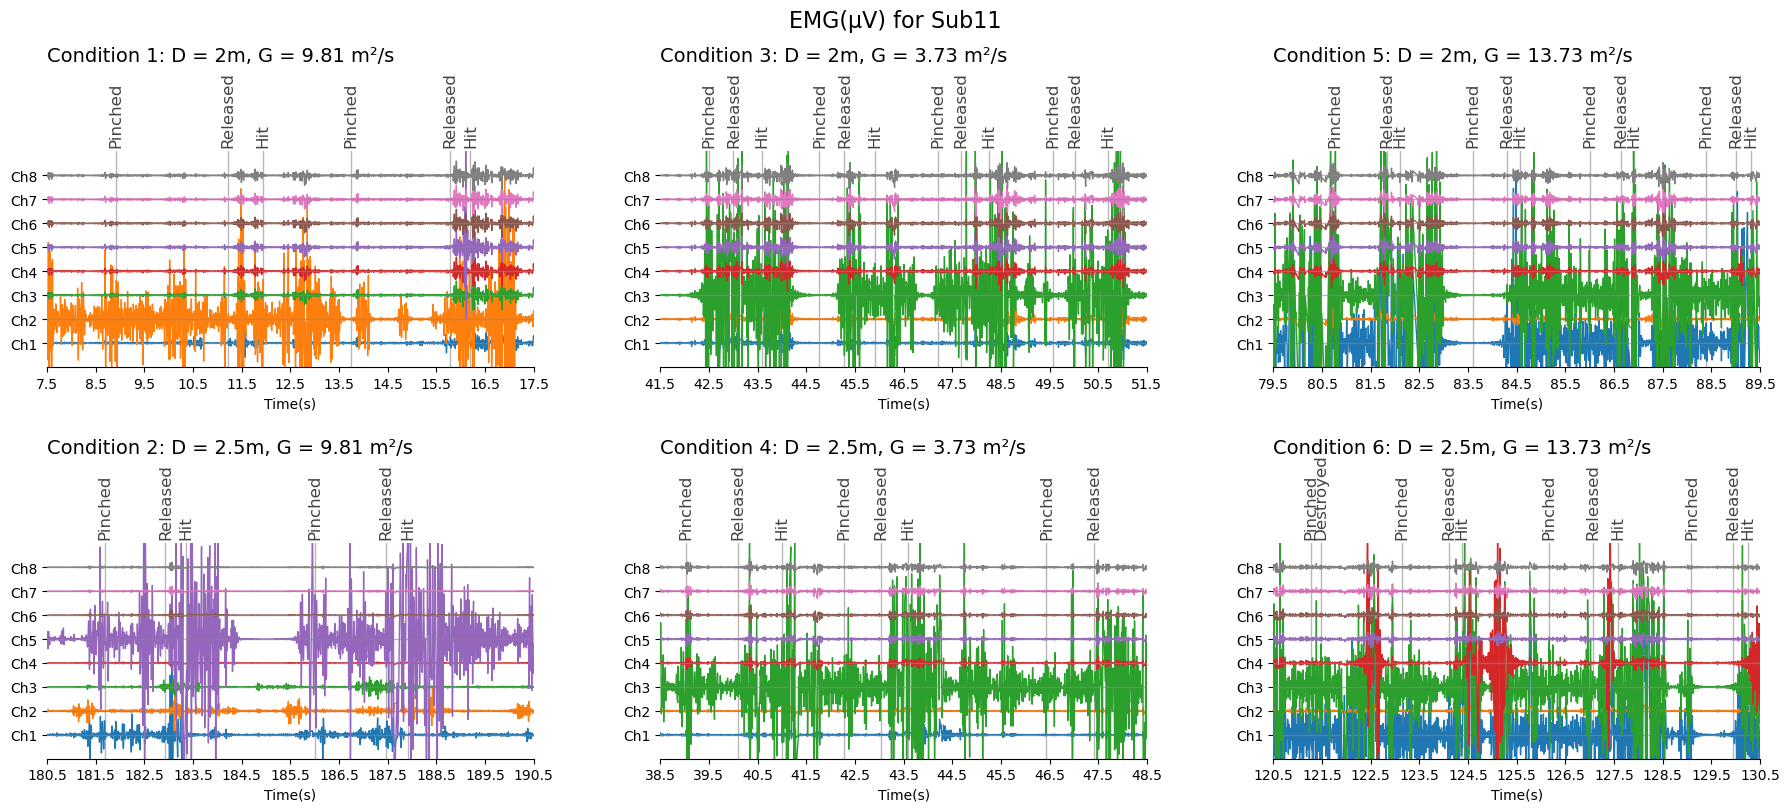

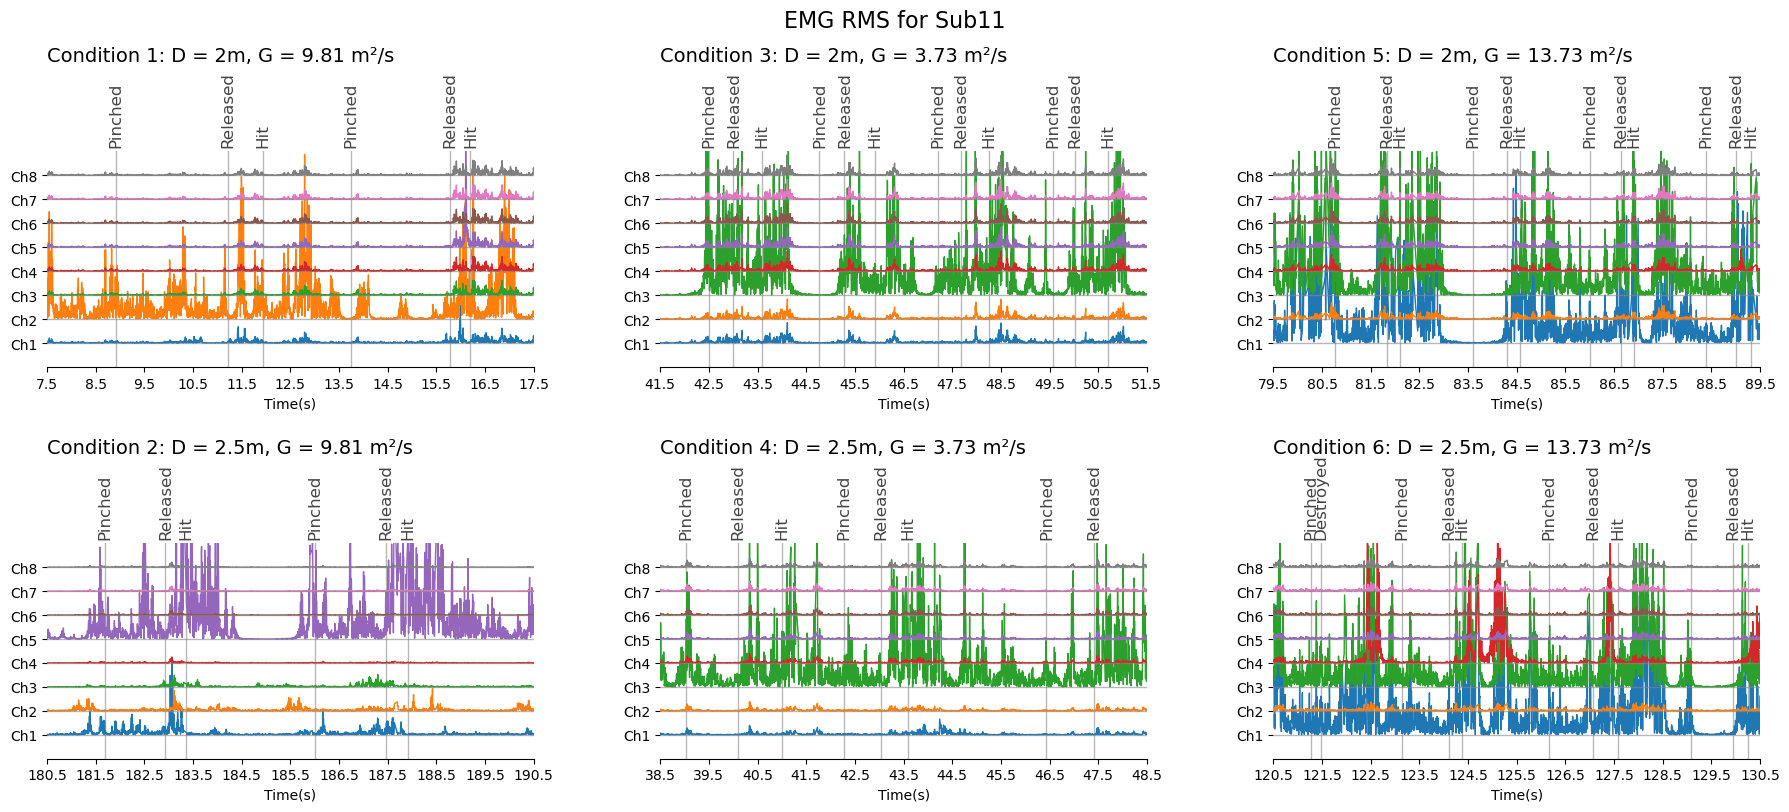

In [66]:
EEG_SAMPLE_RATE_HZ = 250
BANDPASS_LOW_CUT_HZ = 20
BANDPASS_HIGH_CUT_HZ = 120
BANDPASS_ORDER = 6

DISPLAYTIME = float(10)

base = current_phase.data_dir / "1_chopped"

for sub in sub_nums:
    all_emg = []
    all_emg_rms = []
    all_markers = []
    PINCH_STARTS = OW_STARTS[sub]

    for sub_dir in sorted(base.glob(f"sub{sub}_*")):
        for f in sorted(sub_dir.glob("emg_order*_cond*.csv")):
            # corresponding marker file (same order/cond encoded in name)
            marker_name = f.name.replace("emg_", "marker_")
            marker_path = f.parent / marker_name

            if marker_path.exists():
                mk = pd.read_csv(marker_path, usecols=["UnixTime(ms)", "Marker", "Condition"]).copy()
                t0 = mk["UnixTime(ms)"].iloc[0]
                mk["t_rel_s"] = (mk["UnixTime(ms)"] - t0) / 1000.0
                all_markers.append(mk)
            
            # emg df
            df = pd.read_csv(f)
            df_filtered = df.copy()
            channels = [f"Ch{i}" for i in range(1, 9)]
            for ch in channels:
                sig = df[ch].values
                # filter + unit transform
                if len(sig) > 3 * EEG_SAMPLE_RATE_HZ:
                    df_filtered[ch] = bandpass_with_notch(
                        sig,
                        BANDPASS_LOW_CUT_HZ,
                        BANDPASS_HIGH_CUT_HZ,
                        EEG_SAMPLE_RATE_HZ,
                        order=BANDPASS_ORDER
                    )
                    # df_filtered[ch]*=0.0894 #PGA 

            #delete abnormal dataframe
            max_uv=3000
            artifact_mask = (df_filtered[channels].abs() > max_uv).any(axis=1)
            artifact_mask = artifact_mask.rolling(5, center=True, min_periods=1).max().astype(bool)

            df_emg_clean = df_filtered.loc[~artifact_mask].reset_index(drop=True)

            # normalize time per segment start
            df_emg_clean["t_rel_s"] = (df_emg_clean["Timestamp(ms)"] - t0) / 1000.0
            df_emg_clean = df_emg_clean.sort_values(by="t_rel_s")
            
            rms_features = df_emg_clean.copy()
            # RMS feature
            for ch in channels:
                sig = df_emg_clean[ch].values
                rms = np.sqrt(sig**2)
                rms_features[ch] = rms

            all_emg.append(df_emg_clean)
            all_emg_rms.append(rms_features)
            # print(df_filtered.head())


    # if not all_dart:
    #     raise RuntimeError("No chopped dart files found under Phase0_data/1_chopped/")
    
    title_name = f"EMG(μV) for Sub{sub}"
    
    emg_plotter(PINCH_STARTS, all_emg, all_markers, title_name, 400)

    title_name = f"EMG RMS for Sub{sub}"
    
    emg_plotter(PINCH_STARTS, all_emg_rms, all_markers, title_name, 400)


### 3.2.3 EMG time-frequency analysis

sub11, cond1: 2491
sub11, cond3: 2476
sub11, cond5: 2264
sub11, cond2: 2436
sub11, cond4: 2433
sub11, cond6: 2394


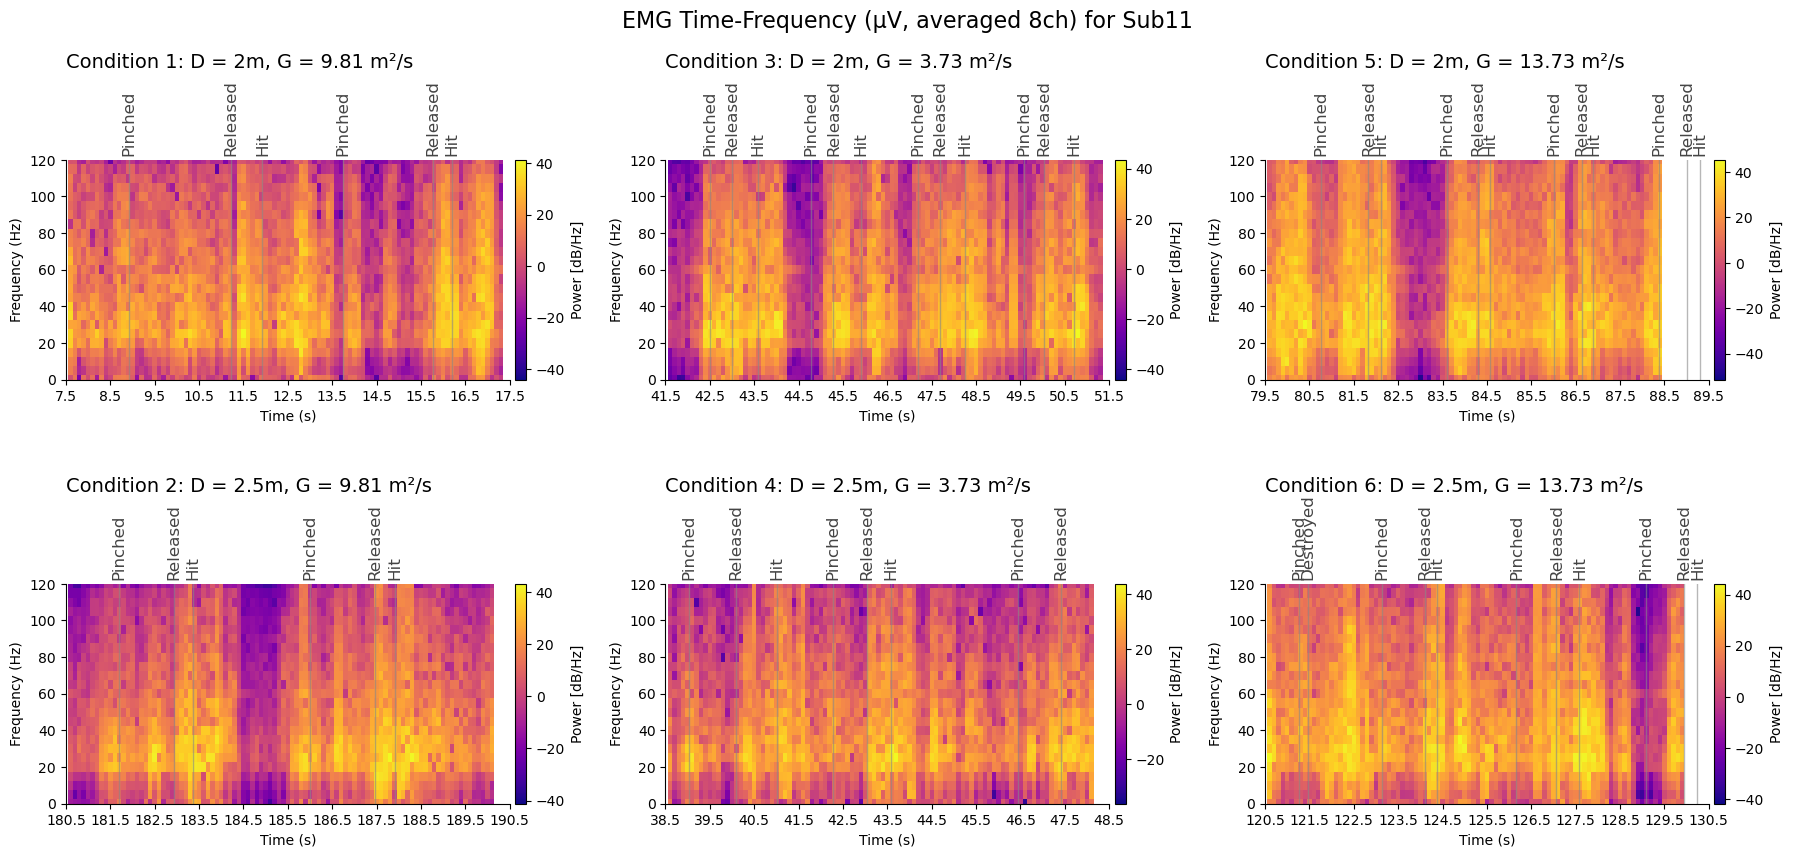

In [67]:
EEG_SAMPLE_RATE_HZ = 250
BANDPASS_LOW_CUT_HZ = 20
BANDPASS_HIGH_CUT_HZ = 120
BANDPASS_ORDER = 6

DISPLAYTIME = float(10)

base = current_phase.data_dir / "1_chopped"

for sub in sub_nums:
    all_emg = []
    all_emg_rms = []
    all_markers = []
    PINCH_STARTS = OW_STARTS[sub]

    for sub_dir in sorted(base.glob(f"sub{sub}_*")):
        for f in sorted(sub_dir.glob("emg_order*_cond*.csv")):
            # corresponding marker file (same order/cond encoded in name)
            marker_name = f.name.replace("emg_", "marker_")
            marker_path = f.parent / marker_name

            if marker_path.exists():
                mk = pd.read_csv(marker_path, usecols=["UnixTime(ms)", "Marker", "Condition"]).copy()
                t0 = mk["UnixTime(ms)"].iloc[0]
                mk["t_rel_s"] = (mk["UnixTime(ms)"] - t0) / 1000.0
                all_markers.append(mk)
            
            # emg df
            df = pd.read_csv(f)
            df_filtered = df.copy()
            channels = [f"Ch{i}" for i in range(1, 9)]
            for ch in channels:
                sig = df[ch].values
                # filter + unit transform
                if len(sig) > 3 * EEG_SAMPLE_RATE_HZ:
                    df_filtered[ch] = bandpass_with_notch(
                        sig,
                        BANDPASS_LOW_CUT_HZ,
                        BANDPASS_HIGH_CUT_HZ,
                        EEG_SAMPLE_RATE_HZ,
                        order=BANDPASS_ORDER
                    )
                    # df_filtered[ch]*=0.0894

            #delete abnormal dataframe
            max_uv=3000
            artifact_mask = (df_filtered[channels].abs() > max_uv).any(axis=1)
            artifact_mask = artifact_mask.rolling(5, center=True, min_periods=1).max().astype(bool)

            df_emg_clean = df_filtered.loc[~artifact_mask].reset_index(drop=True)

            # normalize time per segment start
            df_emg_clean["t_rel_s"] = (df_emg_clean["Timestamp(ms)"] - t0) / 1000.0
            df_emg_clean = df_emg_clean.sort_values(by="t_rel_s")
            
            rms_features = df_emg_clean.copy()
            # RMS feature
            for ch in channels:
                sig = df_emg_clean[ch].values
                rms = np.sqrt(sig**2)
                rms_features[ch] = rms

            all_emg.append(df_emg_clean)
            all_emg_rms.append(rms_features)
            # print(df_filtered.head())


    # if not all_dart:
    #     raise RuntimeError("No chopped dart files found under Phase0_data/1_chopped/")
    
    title_name = f"EMG Time-Frequency (μV, averaged 8ch) for Sub{sub}"
    
    emg_timefreq_plotter(PINCH_STARTS, all_emg, all_markers, title_name)

## 3.3 EEG
### 3.3.1 Utils

In [69]:
def eeg_plotter(ow_starts, all_eeg, all_markers, title, upoffset):
    # legend_items = {
    #     "X": colorDictionary["X"],
    #     "Y": colorDictionary["Y"],
    #     "Z": colorDictionary["Z"]
    # }

    eeg_df = pd.concat(all_eeg, ignore_index=True)
    # hand_df = pd.concat(all_hand, ignore_index=True)
    conditions = condition_mapping.CONDITION_MAPPING.condition_sort(eeg_df, current_phase.cond_order)

    # y_min, y_max = emg_df[["Ch1","Ch2","Ch3","Ch4","Ch5","Ch6","Ch7","Ch8"]].min().min(), emg_df[["Ch1","Ch2","Ch3","Ch4","Ch5","Ch6","Ch7","Ch8"]].max().max()
    y_min = -upoffset
    y_max = upoffset*7

    # one subplot per condition; each subplot has X, Y, Z as lines
    n = len(conditions)
    rows, cols = (n + 1) // 3, 3
    fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 4*rows), sharex=False)
    axes = axes.flatten()
    fig.suptitle(title, fontsize=16, y=1.01)
    # handles = [
    #     plt.Line2D([0], [0], color=colorDictionary["X"], lw=2, label="Dart X", linestyle="-"),
    #     plt.Line2D([0], [0], color=colorDictionary["Y"], lw=2, label="Dart Y", linestyle="-"),
    #     plt.Line2D([0], [0], color=colorDictionary["Z"], lw=2, label="Dart Z", linestyle="-"),
    #     plt.Line2D([0], [0], color=colorDictionary["X"], lw=2, label="Hand X", linestyle="--"),
    #     plt.Line2D([0], [0], color=colorDictionary["Y"], lw=2, label="Hand Y", linestyle="--"),
    #     plt.Line2D([0], [0], color=colorDictionary["Z"], lw=2, label="Hand Z", linestyle="--"),
    # ]
    # fig.legend(handles=handles, loc="upper center", ncol=6, fontsize=10, frameon=False, bbox_to_anchor=(0.5, 1))

    for i, cond in enumerate(conditions):
        ax = axes[i]
        # ax.set_title(f"Condition {cond}\nD = {condition_dict[cond][2]}m, G = {round(condition_dict[cond][-1]*9.81,2)}m^2/s", x=0, y=1.25, ha="left", fontsize=14)
        fig.text(
            0, 1.40, f"Condition {cond}: D = {condition_dict[cond][2]}m, G = {round(condition_dict[cond][-1]*9.81, 2)} m²/s",
            transform=ax.transAxes,
            ha="left", va="bottom", fontsize=14
        )

        # fig.text(
        #     0, 1.23, f"D = {condition_dict[cond][2]}m, G = {round(condition_dict[cond][-1]*9.81, 2)} m²/s",
        #     transform=ax.transAxes,
        #     ha="left", va="bottom", fontsize=12, color="black"
        # )
        
        g = eeg_df[eeg_df["Condition"] == cond]

        mk = None
        if all_markers:
            mk = pd.concat(
                [m for m in all_markers if m["Condition"].iloc[0] == cond],
                ignore_index=True
            ) if any(m["Condition"].iloc[0] == cond for m in all_markers) else None

        if mk is not None and not mk.empty:
            OW_START = ow_starts[cond]
            OW_END = OW_START + DISPLAYTIME
            if OW_END > mk["t_rel_s"].iloc[-1]:
                OW_END = mk["t_rel_s"].iloc[-1]
            
            # get emg data inside OW
            g = g.loc[(g["t_rel_s"] <= OW_END) & (g["t_rel_s"] >= OW_START)]

            mk["Marker"] = mk["Marker"].replace({
                "Low Destroyed": "Destroyed",
                "High Destroyed": "Destroyed"
            })

            mk = mk[mk["Marker"].isin(["Pinched", "Released", "Destroyed", "Hit"])]
            mk = mk.sort_values("t_rel_s")

            for _, row in mk.loc[(mk["t_rel_s"] <= OW_END) & (mk["t_rel_s"] >= OW_START)].iterrows():
                t = row["t_rel_s"]
                label = row["Marker"]

                ax.text(
                    t, 1.02, label,
                    transform=ax.get_xaxis_transform(),
                    rotation=90, ha="center", va="bottom",
                    fontsize=12, color="#444444",
                    clip_on=False
                )

                ax.axvline(t, color="#888888", linestyle="-", linewidth=1, alpha=0.6)
                # ax.text(
                #     t + 0.15, y_min - 4.5,
                #     label, rotation=90, va="bottom", ha="center", fontsize=8, color="#444444"
                # )

        cmap = plt.get_cmap("tab10")

        for i in range(1, 8):
            ax.plot(
                g["t_rel_s"], g[f"Ch{i}"]+(i-1)*upoffset,
                color=cmap(i-1),
                label=f"Ch{i}",
                linewidth=1,
                zorder=2
            )
            ax.axhline((i-1)*upoffset, color="#888888", linestyle="-", linewidth=1, alpha=0.6)

        ax.spines['top'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.spines['right'].set_visible(False)

        ax.set_xlabel("Time(s)")
        # ax.set_ylabel("Position (m)")
        # remove grid per request
        ax.grid(False)
        ax.set_xlim(OW_START, OW_END)
        ax.set_xticks(np.arange(OW_START, OW_END + 1.0, 1.0))
        ax.set_ylim(y_min, y_max)
        ax.set_yticks(np.arange(0, y_max, upoffset))
        ax.set_yticklabels(["Ch1","Ch2","Ch3","Ch4","Ch5","Ch6","Ch7"])
        # ax.legend(loc="lower left", bbox_to_anchor=(1.02, 0.0), frameon=False)

    # remove any unused axes
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout(w_pad=5, h_pad=3)
    plt.show()

In [70]:
from scipy.signal import spectrogram

def eeg_timefreq_plotter(ow_starts, all_emg, all_markers, title, fs=250, fmax=120):
    emg_df = pd.concat(all_emg, ignore_index=True)
    conditions = condition_mapping.CONDITION_MAPPING.condition_sort(emg_df, current_phase.cond_order)
    n = len(conditions)
    rows, cols = (n + 1) // 3, 3
    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 4 * rows), sharex=False)
    axes = axes.flatten()
    fig.suptitle(title, fontsize=16, y=1.05)

    for i, cond in enumerate(conditions):
        ax = axes[i]
        OW_START = ow_starts[cond]
        OW_END = OW_START + DISPLAYTIME - 0.5
        fig.text(
            0, 1.40, f"Condition {cond}: D = {condition_dict[cond][2]}m, G = {round(condition_dict[cond][-1]*9.81, 2)} m²/s",
            transform=ax.transAxes,
            ha="left", va="bottom", fontsize=14
        )

        # fig.text(
        #     0, 1.23, f"D = {condition_dict[cond][2]}m, G = {round(condition_dict[cond][-1]*9.81, 2)} m²/s",
        #     transform=ax.transAxes,
        #     ha="left", va="bottom", fontsize=12, color="black"
        # )

        g = emg_df[emg_df["Condition"] == cond]

        # ====== marker ======
        mk = None
        if all_markers:
            mk = pd.concat(
                [m for m in all_markers if m["Condition"].iloc[0] == cond],
                ignore_index=True
            ) if any(m["Condition"].iloc[0] == cond for m in all_markers) else None

        if mk is not None and not mk.empty:
            
            # get emg data inside OW:
            g = g.loc[(g["t_rel_s"] <= OW_END) & (g["t_rel_s"] >= OW_START)]
            print(f"sub{sub}, cond{cond}: {len(g)}")
                
            mk["Marker"] = mk["Marker"].replace({
                "Low Destroyed": "Destroyed",
                "High Destroyed": "Destroyed"
            })

            mk = mk[mk["Marker"].isin(["Pinched", "Released", "Destroyed", "Hit"])]
            mk = mk.sort_values("t_rel_s")

            for _, row in mk.loc[(mk["t_rel_s"] <= OW_END) & (mk["t_rel_s"] >= OW_START)].iterrows():
                t = row["t_rel_s"]
                label = row["Marker"]

                ax.text(
                    t, 1.02, label,
                    transform=ax.get_xaxis_transform(),
                    rotation=90, ha="center", va="bottom",
                    fontsize=12, color="#444444",
                    clip_on=False
                )

                ax.axvline(t, color="#888888", linestyle="-", linewidth=1, alpha=0.6)
                # ax.text(
                #     t + 0.15, y_min - 4.5,
                #     label, rotation=90, va="bottom", ha="center", fontsize=8, color="#444444"
                # )

        # ====== mean 8 chs ======
        Sxx_all = []
        channels = [f"Ch{i}" for i in range(1, 8)]
        for ch in channels:
            sig = g[ch].values
            if len(sig) > 3 * fs:
                f, t, Sxx = spectrogram(sig, fs=fs, nperseg=50, noverlap=25, scaling='density')
                t = t + OW_START
                Sxx_all.append(Sxx)

        if len(Sxx_all) == 0:
            continue

        Sxx_mean = np.mean(Sxx_all, axis=0)
        pcm = ax.pcolormesh(t, f, 10 * np.log10(Sxx_mean + 1e-12),
                            shading='auto', cmap='plasma', zorder=1)
        ax.set_ylim(0, fmax)
        ax.set_xlim(OW_START, OW_END)
        ax.set_xticks(np.arange(OW_START, OW_END + 1.0, 1.0))
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Frequency (Hz)")
        fig.colorbar(pcm, ax=ax, label="Power [dB/Hz]", pad=0.01)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    # fig.colorbar(pcm, ax=axes, label="Power (dB)", pad=0.02)
    plt.tight_layout(pad=0.2, w_pad=0.3, h_pad=5)
    
    plt.show()

### 3.3.2 EEG waveform

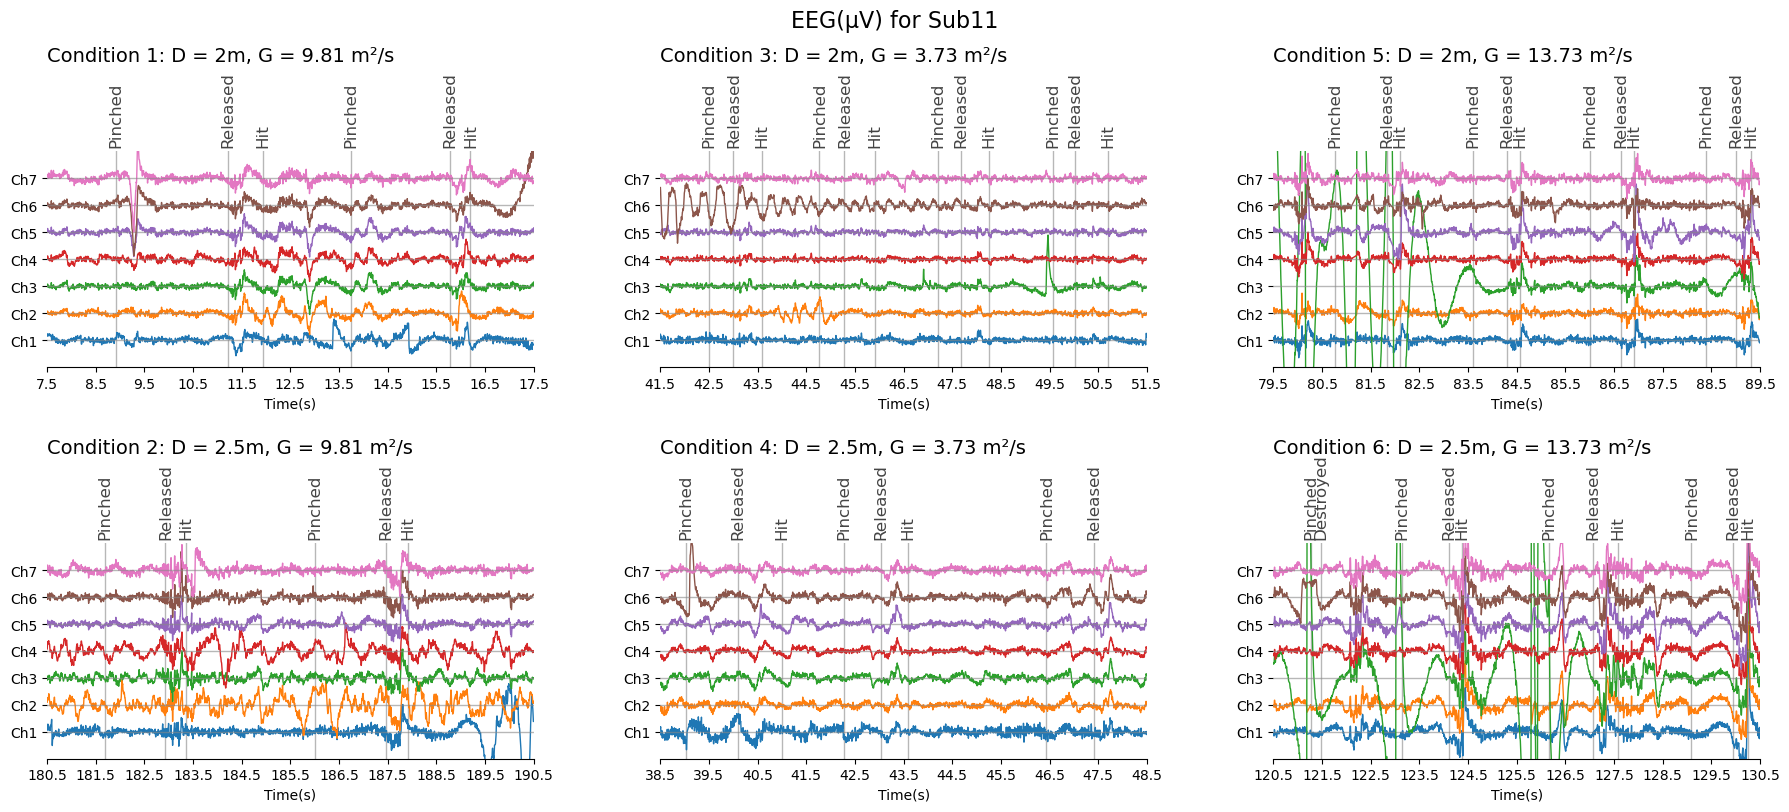

In [71]:
EEG_SAMPLE_RATE_HZ = 250
BANDPASS_LOW_CUT_HZ = 1
BANDPASS_HIGH_CUT_HZ = 80
BANDPASS_ORDER = 6

DISPLAYTIME = float(10)

base = current_phase.data_dir / "1_chopped"

for sub in sub_nums:
    all_eeg = []
    all_markers = []
    PINCH_STARTS = OW_STARTS[sub]

    for sub_dir in sorted(base.glob(f"sub{sub}_*")):
        for f in sorted(sub_dir.glob("eeg_order*_cond*.csv")):
            # corresponding marker file (same order/cond encoded in name)
            marker_name = f.name.replace("eeg_", "marker_")
            marker_path = f.parent / marker_name

            if marker_path.exists():
                mk = pd.read_csv(marker_path, usecols=["UnixTime(ms)", "Marker", "Condition"]).copy()
                t0 = mk["UnixTime(ms)"].iloc[0]
                mk["t_rel_s"] = (mk["UnixTime(ms)"] - t0) / 1000.0
                all_markers.append(mk)
            
            # emg df
            df = pd.read_csv(f)
            df_filtered = df.copy()
            channels = [f"Ch{i}" for i in range(1, 9)]
            for ch in channels:
                sig = df[ch].values
                # filter + unit transform
                if len(sig) > 3 * EEG_SAMPLE_RATE_HZ:
                    df_filtered[ch] = bandpass_with_notch(
                        sig,
                        BANDPASS_LOW_CUT_HZ,
                        BANDPASS_HIGH_CUT_HZ,
                        EEG_SAMPLE_RATE_HZ,
                        order=BANDPASS_ORDER
                    )
                    # df_filtered[ch] = df_filtered[ch]
                    # df_filtered[ch]*=0.022

            #delete abnormal dataframe
            max_uv=3000
            artifact_mask = (df_filtered[channels].abs() > max_uv).any(axis=1)
            artifact_mask = artifact_mask.rolling(5, center=True, min_periods=1).max().astype(bool)

            df_eeg_clean = df_filtered.loc[~artifact_mask].reset_index(drop=True)

            # normalize time per segment start
            df_eeg_clean["t_rel_s"] = (df_eeg_clean["Timestamp(ms)"] - t0) / 1000.0
            df_eeg_clean = df_eeg_clean.sort_values(by="t_rel_s")
            
            rms_features = df_eeg_clean.copy()
            # RMS feature
            for ch in channels:
                sig = df_eeg_clean[ch].values
                rms = np.sqrt(sig**2)
                rms_features[ch] = rms

            all_eeg.append(df_eeg_clean)
            # print(df_filtered.head())


    # if not all_dart:
    #     raise RuntimeError("No chopped dart files found under Phase0_data/1_chopped/")
    
    title_name = f"EEG(μV) for Sub{sub}"
    
    eeg_plotter(PINCH_STARTS, all_eeg, all_markers, title_name, 200)


### 3.3.3 EEG time-frequency analysis

sub11, cond1: 2378
sub11, cond3: 2378
sub11, cond5: 2372
sub11, cond2: 2378
sub11, cond4: 2378
sub11, cond6: 2376


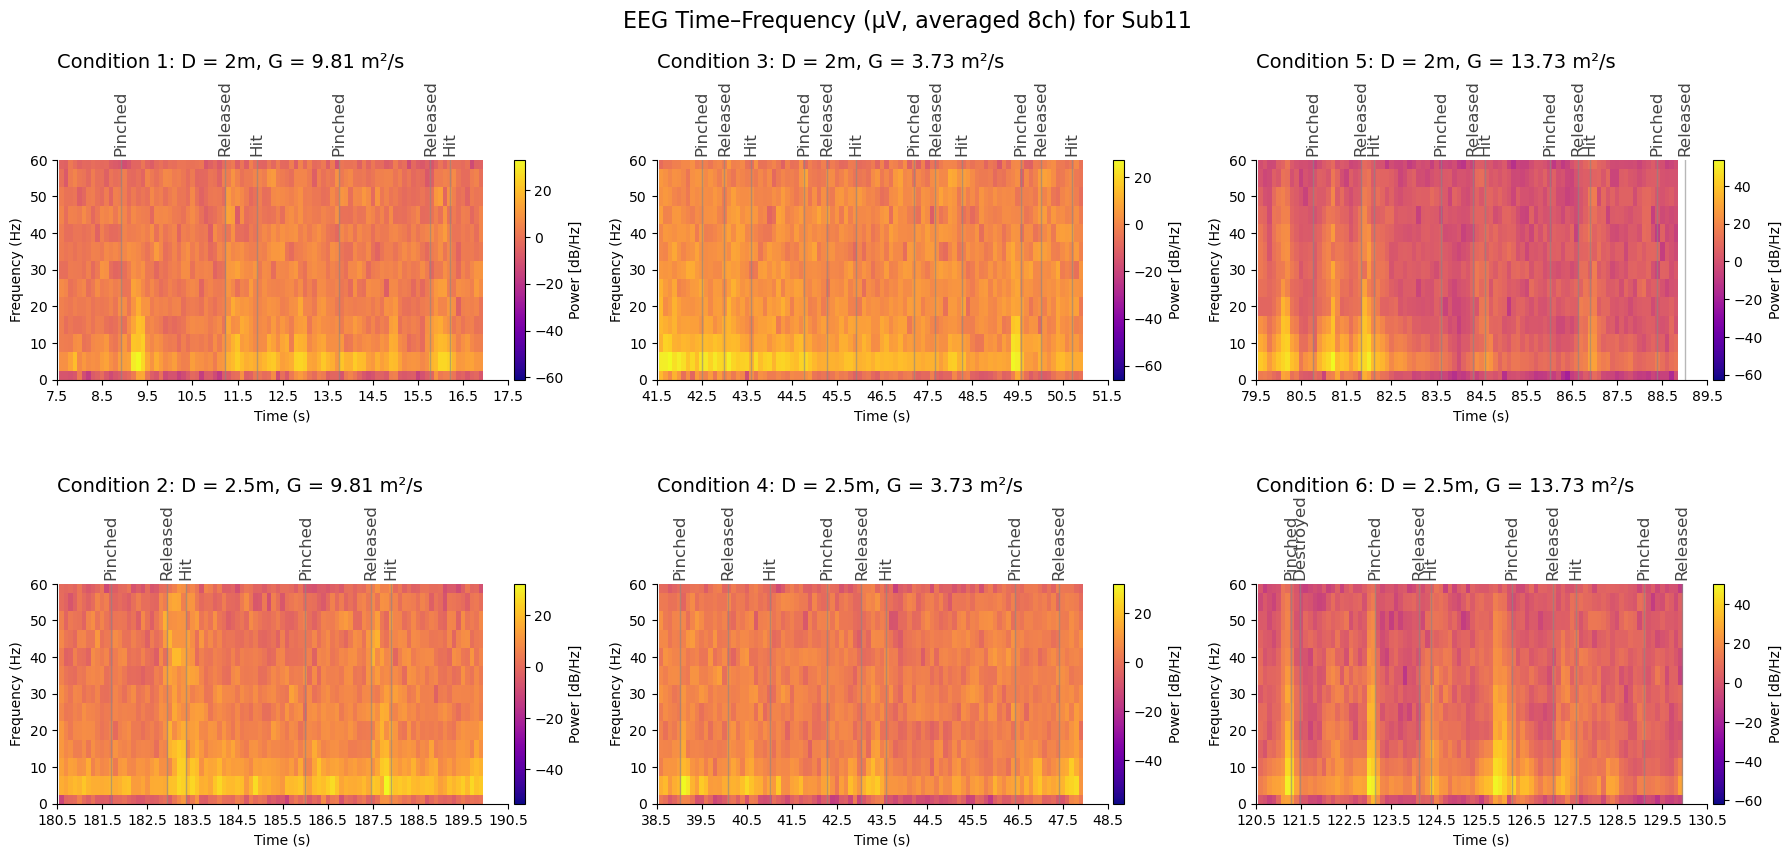

In [ ]:
EEG_SAMPLE_RATE_HZ = 250
BANDPASS_LOW_CUT_HZ = 1
BANDPASS_HIGH_CUT_HZ = 80
BANDPASS_ORDER = 6

DISPLAYTIME = float(10)

base = base_dir / "1_chopped"

for sub in sub_nums:
    all_eeg = []
    all_markers = []
    PINCH_STARTS = OW_STARTS[sub]

    for sub_dir in sorted(base.glob(f"sub{sub}_*")):
        for f in sorted(sub_dir.glob("eeg_order*_cond*.csv")):
            # corresponding marker file (same order/cond encoded in name)
            marker_name = f.name.replace("eeg_", "marker_")
            marker_path = f.parent / marker_name

            if marker_path.exists():
                mk = pd.read_csv(marker_path, usecols=["UnixTime(ms)", "Marker", "Condition"]).copy()
                t0 = mk["UnixTime(ms)"].iloc[0]
                mk["t_rel_s"] = (mk["UnixTime(ms)"] - t0) / 1000.0
                all_markers.append(mk)
            
            # emg df
            df = pd.read_csv(f)
            df_filtered = df.copy()
            channels = [f"Ch{i}" for i in range(1, 9)]
            for ch in channels:
                sig = df[ch].values
                # filter + unit transform
                if len(sig) > 3 * EEG_SAMPLE_RATE_HZ:
                    df_filtered[ch] = bandpass_with_notch(
                        sig,
                        BANDPASS_LOW_CUT_HZ,
                        BANDPASS_HIGH_CUT_HZ,
                        EEG_SAMPLE_RATE_HZ,
                        order=BANDPASS_ORDER
                    )
                    # df_filtered[ch]*=0.022

            #delete abnormal dataframe
            max_uv=100000
            artifact_mask = (df_filtered[channels].abs() > max_uv).any(axis=1)
            artifact_mask = artifact_mask.rolling(5, center=True, min_periods=1).max().astype(bool)

            df_eeg_clean = df_filtered.loc[~artifact_mask].reset_index(drop=True)

            # normalize time per segment start
            df_eeg_clean["t_rel_s"] = (df_eeg_clean["Timestamp(ms)"] - t0) / 1000.0
            df_eeg_clean = df_eeg_clean.sort_values(by="t_rel_s")
            
            rms_features = df_eeg_clean.copy()
            # RMS feature
            for ch in channels:
                sig = df_eeg_clean[ch].values
                rms = np.sqrt(sig**2)
                rms_features[ch] = rms

            all_eeg.append(df_eeg_clean)
            # print(df_filtered.head())


    # if not all_dart:
    #     raise RuntimeError("No chopped dart files found under Phase0_data/1_chopped/")
    
    title_name = f"EEG Time-Frequency (μV, averaged 8ch) for Sub{sub}"
    
    eeg_timefreq_plotter(PINCH_STARTS, all_eeg, all_markers, title_name, fmax=60)


## 3.3 Eye
### 3.3.1 Pupil diameter


In [73]:
# Visualize eye pupil diameter by condition over time

EYE_DISPLAYTIME = float(10)

base = base_dir / "1_chopped"

# filtering config
FILTER_CUTOFF_HZ = 10.0  # configurable low-pass cutoff (Hz)
FILTER_ORDER = 6

from scipy.signal import butter, sosfiltfilt

# columns in eye chopped CSVs
LEFT_PUPIL_COL = "Left Pupil Diameter (mm)"
RIGHT_PUPIL_COL = "Right Pupil Diameter (mm)"
EYE_TIME_COL = "Capture Unix timestamp"

def eye_plotter(ow_starts, all_eye, all_markers, title):
    eye_df = pd.concat(all_eye, ignore_index=True)

    conditions = condition_mapping.CONDITION_MAPPING.condition_sort(eye_df, current_phase.cond_order)

    # Compute y limits across both eyes
    y_min = eye_df[[LEFT_PUPIL_COL, RIGHT_PUPIL_COL]].min().min()
    y_max = eye_df[[LEFT_PUPIL_COL, RIGHT_PUPIL_COL]].max().max()
    y_min, y_max = 0, 10

    n = len(conditions)
    rows, cols = (n + 1) // 3, 3
    fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 4*rows), sharex=False)
    axes = axes.flatten()
    fig.suptitle(title, fontsize=16, y=1.07)

    handles = [
        plt.Line2D([0], [0], color="#0095ff", lw=2, label="Left pupil (mm)", linestyle="-"),
        plt.Line2D([0], [0], color="#ff0000", lw=2, label="Right pupil (mm)", linestyle="-"),
    ]
    fig.legend(handles=handles, loc="upper center", ncol=2, fontsize=10, frameon=False, bbox_to_anchor=(0.5, 1.05))

    for i, cond in enumerate(conditions):
        ax = axes[i]
        fig.text(
            0, 1.40, f"Condition {cond}: D = {condition_dict[cond][2]}m, G = {round(condition_dict[cond][-1]*9.81, 2)} m²/s",
            transform=ax.transAxes,
            ha="left", va="bottom", fontsize=14
        )

        # fig.text(
        #     0, 1.23, f"D = {condition_dict[cond][2]}m, G = {round(condition_dict[cond][-1]*9.81, 2)} m²/s",
        #     transform=ax.transAxes,
        #     ha="left", va="bottom", fontsize=12, color="black"
        # )

        g = eye_df[eye_df["Condition"] == cond]

        mk = None
        if all_markers:
            mk = pd.concat(
                [m for m in all_markers if m["Condition"].iloc[0] == cond],
                ignore_index=True
            ) if any(m["Condition"].iloc[0] == cond for m in all_markers) else None

        # plot markers as vertical lines with labels similar to dart plot
        if mk is not None and not mk.empty:
            mk = mk.copy()
            OW_START = ow_starts[cond]
            OW_END = OW_START + EYE_DISPLAYTIME
            
            # get emg data inside OW:
            g = g.loc[(g["t_rel_s"] <= OW_END) & (g["t_rel_s"] >= OW_START)]

            mk["Marker"] = mk["Marker"].replace({
                "Low Destroyed": "Destroyed",
                "High Destroyed": "Destroyed"
            })
            mk = mk[mk["Marker"].isin(["Pinched", "Released", "Destroyed", "Hit"])].sort_values("t_rel_s")

            # restrict labels/lines strictly within [0, EYE_DISPLAYTIME]
            mk_in = mk[(mk["t_rel_s"] >= OW_START) & (mk["t_rel_s"] <= OW_END)]
            for _, row in mk_in.iterrows():
                t = row["t_rel_s"]
                label = row["Marker"]
                ax.text(t, 1.02, label, transform=ax.get_xaxis_transform(), rotation=90, ha="center", va="bottom", fontsize=12, color="#444444", clip_on=False)
                ax.axvline(t, color="#888888", linestyle="-", linewidth=1, alpha=0.6)

        # pick filtered if available
        left_col = "LeftPupil_filtered"
        right_col = "RightPupil_filtered"
        if left_col not in g.columns or right_col not in g.columns:
            left_col = LEFT_PUPIL_COL
            right_col = RIGHT_PUPIL_COL

        ax.plot(g["t_rel_s"], g[left_col], color="#0095ff", linewidth=2.0, alpha=0.9, zorder=3)
        ax.plot(g["t_rel_s"], g[right_col], color="#ff0000", linewidth=2.0, alpha=0.9, zorder=3)

        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Pupil diameter (mm)")
        ax.grid(False)
        ax.set_xlim(OW_START, OW_END)
        ax.set_xticks(np.arange(OW_START, OW_END + 1.0, 1.0))
        ax.set_ylim(y_min, y_max)

    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout(w_pad=5, h_pad=3)
    plt.show()

/var/folders/ld/ydrxs2j90nx98nz_s4zpd5l80000gn/T/ipykernel_6027/914397012.py:40: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df["LeftPupil_filtered"] = sosfiltfilt(sos, pd.to_numeric(df[LEFT_PUPIL_COL], errors='coerce').interpolate(limit_direction='both').fillna(method='bfill').fillna(method='ffill'))
/var/folders/ld/ydrxs2j90nx98nz_s4zpd5l80000gn/T/ipykernel_6027/914397012.py:41: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df["RightPupil_filtered"] = sosfiltfilt(sos, pd.to_numeric(df[RIGHT_PUPIL_COL], errors='coerce').interpolate(limit_direction='both').fillna(method='bfill').fillna(method='ffill'))
/var/folders/ld/ydrxs2j90nx98nz_s4zpd5l80000gn/T/ipykernel_6027/914397012.py:40: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() inste

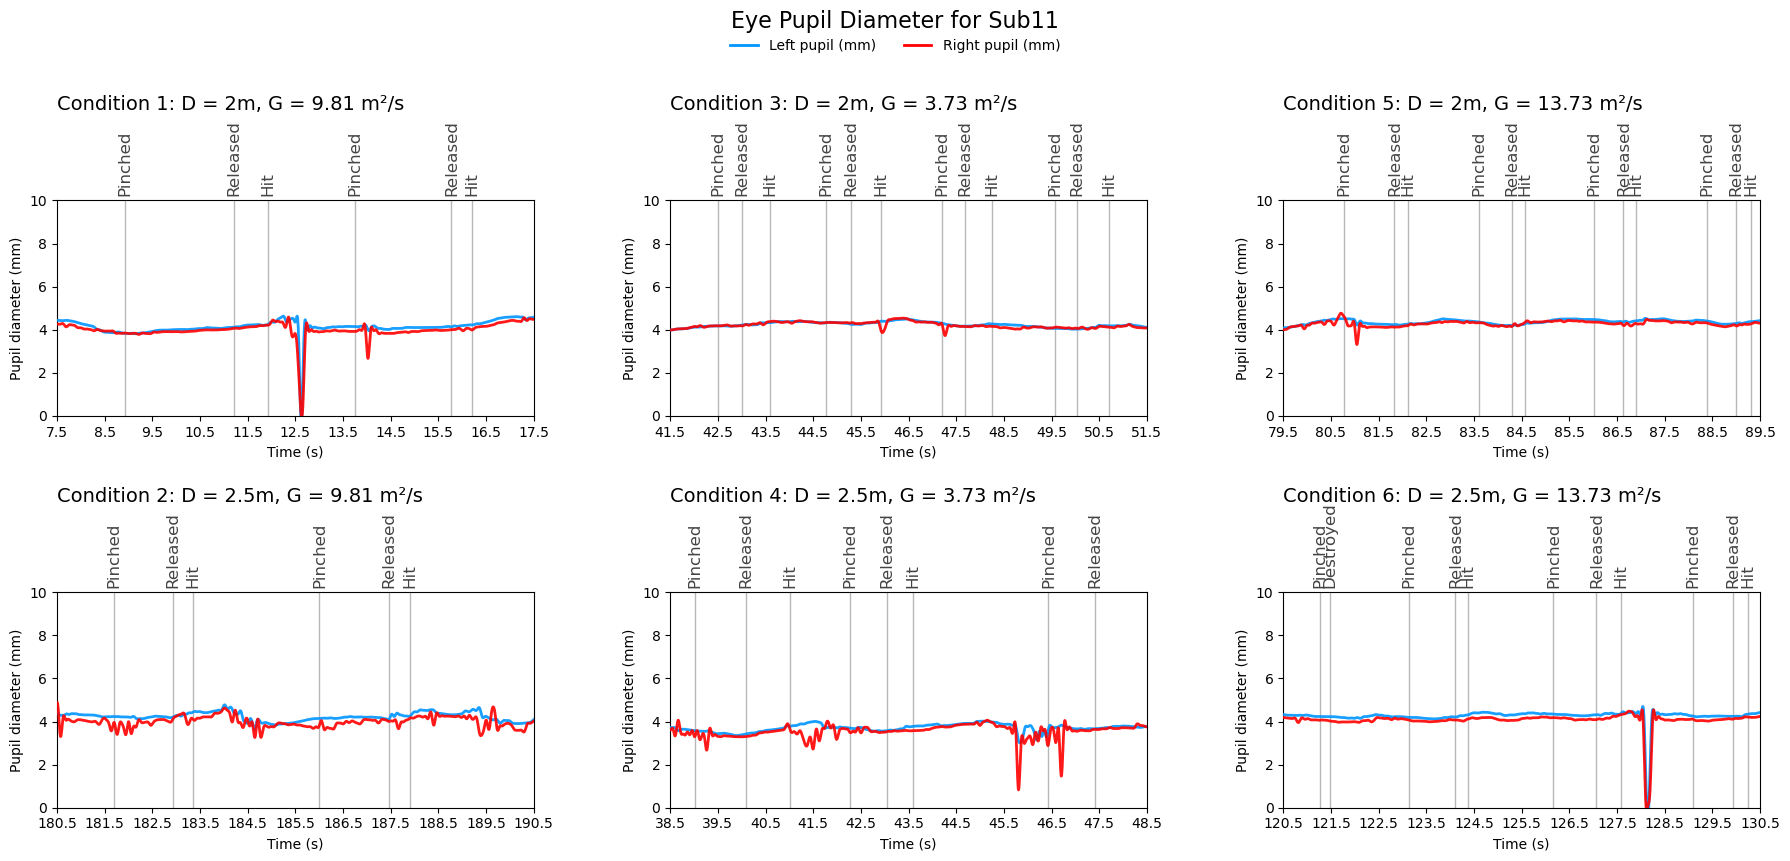

In [74]:
for sub in sub_nums:
    all_eye = []
    all_markers = []
    PINCH_STARTS = OW_STARTS[sub]

    for sub_dir in sorted(base.glob(f"sub{sub}_*")):
        for f in sorted(sub_dir.glob("eye_order*_cond*.csv")):
            usecols = [
                "Condition",
                LEFT_PUPIL_COL, RIGHT_PUPIL_COL, EYE_TIME_COL
            ]
            df = pd.read_csv(f, usecols=usecols)

            # Determine t0_ms from the 2nd "Pinch Condition Passed" marker if available,
            # else the 1st such marker, else the earliest marker, else the first eye timestamp
            marker_name = f.name.replace("eye_", "marker_")
            marker_path = f.parent / marker_name

            eye_time_ms = (pd.to_numeric(df[EYE_TIME_COL], errors="coerce") // 1_000_000).astype("Int64")
            if marker_path.exists():
                mk = pd.read_csv(marker_path, usecols=["UnixTime(ms)", "Marker", "Condition"]).copy()
                t0_ms = mk["UnixTime(ms)"].iloc[0]

            # Relative time using chosen t0_ms
            df["t_rel_s"] = (eye_time_ms - t0_ms) / 1000.0

            # infer sampling rate from eye_time_ms spacing; then filter
            # Use robust median dt to reduce impact of jitter
            valid_ms = eye_time_ms.dropna().astype(float).to_numpy()
            if len(valid_ms) >= 5:
                dts = np.diff(valid_ms)
                med_dt_ms = np.median(dts[dts > 0]) if np.any(dts > 0) else None
                if med_dt_ms is not None and med_dt_ms > 0:
                    fs = 1000.0 / med_dt_ms
                    nyq = 0.5 * fs
                    wn = min(FILTER_CUTOFF_HZ / nyq, 0.99) if nyq > 0 else None
                    if wn is not None and wn > 0:
                        sos = butter(N=FILTER_ORDER, Wn=wn, btype='low', output='sos')
                        try:
                            df["LeftPupil_filtered"] = sosfiltfilt(sos, pd.to_numeric(df[LEFT_PUPIL_COL], errors='coerce').interpolate(limit_direction='both').fillna(method='bfill').fillna(method='ffill'))
                            df["RightPupil_filtered"] = sosfiltfilt(sos, pd.to_numeric(df[RIGHT_PUPIL_COL], errors='coerce').interpolate(limit_direction='both').fillna(method='bfill').fillna(method='ffill'))
                        except Exception:
                            # fallback: no filtering if instability
                            df["LeftPupil_filtered"] = pd.to_numeric(df[LEFT_PUPIL_COL], errors='coerce')
                            df["RightPupil_filtered"] = pd.to_numeric(df[RIGHT_PUPIL_COL], errors='coerce')

            all_eye.append(df)

            # Add markers with same t0_ms
            if marker_path.exists():
                mk["t_rel_s"] = (mk["UnixTime(ms)"] - t0_ms) / 1000.0
                all_markers.append(mk)

    if not all_eye:
        continue

    title_name = f"Eye Pupil Diameter for Sub{sub}"
    eye_plotter(PINCH_STARTS, all_eye, all_markers, title_name)

## 3.4 Finger
### 3.4.1 Finger velocity

This section creates a line graph showing the 3D velocity of each finger over time, normalized by subtracting the average velocity of all five fingers.

In [ ]:
# Constants for hand position analysis
HAND_DISPLAYTIME = 20.0  # Display time in seconds
FINGER_NAMES = ['Thumb', 'Index', 'Middle', 'Ring', 'Little']
FINGER_COLORS = ["#FF0000", "#1900FF", "#FF7B00", "#00FF22", "#FFEE00"]

# Filtering parameters for hand velocity (similar to eye data)
HAND_FILTER_CUTOFF_HZ = 5.0  # Lower cutoff for hand velocity (more smoothing)
HAND_FILTER_ORDER = 4  # Lower order for stability

# Bone indices for each finger (corrected mapping based on actual data structure)
# Data has bones 0-15, so we need to map them to 5 fingers
FINGER_BONE_INDICES = {
    0: [0, 1, 2, 3],    # Thumb
    1: [4, 5, 6, 7],    # Index
    2: [8, 9, 10, 11],  # Middle  
    3: [12, 13, 14, 15], # Ring
    4: [0, 1, 2, 3]     # Pinkie (using same as thumb for now - need to verify actual mapping)
}

NORMALIZE = "zscore"

def calculate_finger_velocity(df, finger_idx):
    """Calculate 3D velocity for a specific finger using bone positions or finger speed"""
    # First try to use finger speed if available
    speed_col = f'finger_{finger_idx}_spd'
    if speed_col in df.columns:
        velocity = df[speed_col].values
    else:
        # Fallback to bone position calculation
        bone_indices = FINGER_BONE_INDICES[finger_idx]
        
        # Get positions for all bones of this finger
        positions = []
        for bone_idx in bone_indices:
            x_col = f'bone_{bone_idx}_x'
            y_col = f'bone_{bone_idx}_y' 
            z_col = f'bone_{bone_idx}_z'
            
            if x_col in df.columns and y_col in df.columns and z_col in df.columns:
                pos = np.sqrt(df[x_col]**2 + df[y_col]**2 + df[z_col]**2)
                positions.append(pos)
        
        if not positions or len(df) < 2:
            return np.zeros(len(df))
        
        # Average position across all bones of this finger
        avg_position = np.mean(positions, axis=0)
        
        # Calculate velocity as difference between consecutive positions
        # Use finite differences for small arrays, gradient for larger ones
        if len(avg_position) < 3:
            # For very small arrays, use simple difference
            velocity = np.zeros_like(avg_position)
            if len(avg_position) > 1:
                velocity[1:] = np.diff(avg_position)
        else:
            velocity = np.gradient(avg_position)
    
    return velocity

def apply_hand_velocity_filter(velocity_data, df):
    """Apply low-pass filter to hand velocity data similar to eye data"""
    if len(velocity_data) < 10:  # Need minimum data points for filtering
        return velocity_data
    
    try:
        # Calculate sampling rate from time differences
        if 't_rel_s' in df.columns and len(df) > 1:
            time_diffs = np.diff(df['t_rel_s'].values)
            med_dt_s = np.median(time_diffs[time_diffs > 0])
            if med_dt_s > 0:
                fs = 1.0 / med_dt_s
                nyq = 0.5 * fs
                wn = min(HAND_FILTER_CUTOFF_HZ / nyq, 0.99) if nyq > 0 else None
                
                if wn is not None and wn > 0:
                    from scipy.signal import butter, sosfiltfilt
                    sos = butter(N=HAND_FILTER_ORDER, Wn=wn, btype='low', output='sos')
                    
                    # Clean the data before filtering
                    clean_velocity = pd.Series(velocity_data).interpolate(limit_direction='both').fillna(method='bfill').fillna(method='ffill')
                    filtered_velocity = sosfiltfilt(sos, clean_velocity.values)
                    return filtered_velocity
    except Exception as e:
        print(f"Filtering failed: {e}")
    
    return velocity_data

def center_finger_velocities(velocities, method):
    """Normalize each finger velocity by subtracting the average of all five fingers"""
    # Calculate average velocity across all fingers
    avg_velocity = np.mean(velocities, axis=0)
    std_velocity = np.std(velocities, axis=0)

    normalized_velocities = []

    if method == "fingers_zscore":
        for finger_vel in velocities:
            normalized_vel = (finger_vel - avg_velocity) / std_velocity
            normalized_velocities.append(normalized_vel)
    else:
        for finger_vel in velocities:
            normalized_vel = finger_vel - avg_velocity
            normalized_velocities.append(normalized_vel)
    
    return normalized_velocities

def normalize_finger_velocities(velocities, method):
    avg_velocity = np.mean(velocities, axis=1, keepdims=True) # (i,)
    max_velocity = np.max(velocities, axis=1, keepdims=True) # (i,)
    std_velocity = np.std(velocities, axis=1, keepdims=True) # (i,)

    if method == "zscore":
        normalized_vels = (velocities - avg_velocity) / std_velocity
    elif method == "minmax":
        normalized_vels = velocities / max_velocity
    else:
        normalized_vels = velocities / max_velocity

    return normalized_vels


In [76]:
def hand_velocity_plotter(ow_starts, all_hand_data, all_markers, title):
    """Create hand velocity visualization similar to eye_plotter"""
    hand_df = pd.concat(all_hand_data, ignore_index=True)
    
    conditions = condition_mapping.CONDITION_MAPPING.condition_sort(hand_df,current_phase.cond_order)
    
    # Compute y limits across all fingers for all conditions
    all_velocities = []
    print(f"Found conditions: {conditions}")
    print(f"Total data points: {len(hand_df)}")
    print(f"Time range: [{hand_df['t_rel_s'].min():.2f}, {hand_df['t_rel_s'].max():.2f}] seconds")
    
    for cond in conditions:
        OW_START = ow_starts[cond]
        OW_END = OW_START + HAND_DISPLAYTIME
        g = hand_df[hand_df["Condition"] == cond]
        print(f"  Condition {cond}: {len(g)} data points before time filtering")
        print(f"    Time range: [{g['t_rel_s'].min():.2f}, {g['t_rel_s'].max():.2f}] seconds")
        
        # Use a more flexible time filtering - take first 10 seconds or all data if less than 10 seconds
        if len(g) > 0:
            # Take first 5 seconds of data, or all data if less than 5 seconds
            g_filtered = g.loc[(g["t_rel_s"] <= OW_END) & (g["t_rel_s"] >= OW_START)]
            print(f"    After time filtering: {len(g_filtered)} data points")
            
            if len(g_filtered) > 0:
                # Calculate velocities for all fingers
                finger_vels = []
                for finger_idx in range(5):
                    finger_vel = calculate_finger_velocity(g_filtered, finger_idx)
                    # Apply low-pass filter to smooth the velocity
                    filtered_vel = apply_hand_velocity_filter(finger_vel, g_filtered)
                    finger_vels.append(filtered_vel)
                    print(f"    Finger {finger_idx}: velocity range [{np.min(filtered_vel):.3f}, {np.max(filtered_vel):.3f}]")
                
                # center velocities
                # centered_vels = center_finger_velocities(finger_vels, method="subtract")
                centered_vels = finger_vels
                # normalize velocities
                normalized_vels = normalize_finger_velocities(np.array(centered_vels), method=NORMALIZE)

                all_velocities.extend(np.concatenate(normalized_vels))
                print(f"    Total normalized velocities: {len(np.concatenate(normalized_vels))}")
            else:
                print(f"    No data after time filtering for condition {cond}")
        else:
            print(f"    No data for condition {cond}")
    
    if not all_velocities:
        print("No valid velocity data found")
        return
    
    # Use full range of velocities to show all values
    if NORMALIZE == "zscore":
        y_min = -4
        y_max = 4
    else:
        y_min = np.min(all_velocities)
        y_max = np.max(all_velocities)
    
    # Add some padding to the range for better visualization
    y_range = y_max - y_min
    y_padding = y_range * 0.1  # 10% padding
    y_min = y_min - y_padding
    y_max = y_max + y_padding
    
    n = len(conditions)
    rows, cols = (n + 1) // 3, 3
    fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 4*rows), sharex=False)
    axes = axes.flatten()
    fig.suptitle(title, fontsize=16, y=1.07)
    
    # Create legend handles
    handles = []
    for i, (name, color) in enumerate(zip(FINGER_NAMES, FINGER_COLORS)):
        handles.append(plt.Line2D([0], [0], color=color, lw=2, label=f"{name}", linestyle="-"))
    
    fig.legend(handles=handles, loc="upper center", ncol=5, fontsize=10, frameon=False, bbox_to_anchor=(0.5, 1.05))
    
    for i, cond in enumerate(conditions):
        OW_START = ow_starts[cond]
        OW_END = OW_START + HAND_DISPLAYTIME
        ax = axes[i]
        fig.text(
            0, 1.40, f"Condition {cond}: D = {condition_dict[cond][2]}m, G = {round(condition_dict[cond][-1]*9.81, 2)} m²/s",
            transform=ax.transAxes,
            ha="left", va="bottom", fontsize=14
        )

        # fig.text(
        #     0, 1.23, f"D = {condition_dict[cond][2]}m, G = {round(condition_dict[cond][-1]*9.81, 2)} m²/s",
        #     transform=ax.transAxes,
        #     ha="left", va="bottom", fontsize=12, color="black"
        # )
        
        g = hand_df[hand_df["Condition"] == cond]
        # Use flexible time filtering
        if len(g) > 0:
            g = g.loc[(g["t_rel_s"] <= OW_END) & (g["t_rel_s"] >= OW_START)]
        
        # Plot markers as vertical lines
        mk = None
        if all_markers:
            mk = pd.concat(
                [m for m in all_markers if m["Condition"].iloc[0] == cond],
                ignore_index=True
            ) if any(m["Condition"].iloc[0] == cond for m in all_markers) else None
        
        if mk is not None and not mk.empty:
            mk = mk.copy()
            mk["Marker"] = mk["Marker"].replace({
                "Low Destroyed": "Destroyed",
                "High Destroyed": "Destroyed"
            })
            mk = mk[mk["Marker"].isin(["Pinched", "Released", "Destroyed", "Hit"])].sort_values("t_rel_s")
            
            mk_in = mk[(mk["t_rel_s"] >= OW_START) & (mk["t_rel_s"] <= OW_END)]
            for _, row in mk_in.iterrows():
                t = row["t_rel_s"]
                label = row["Marker"]
                ax.text(t, 1.02, label, transform=ax.get_xaxis_transform(), rotation=90, ha="center", va="bottom", fontsize=12, color="#444444", clip_on=False)
                ax.axvline(t, color="#888888", linestyle="-", linewidth=1, alpha=0.6)
        
        # Calculate and plot velocities for each finger
        if len(g) > 0:
            finger_vels = []
            for finger_idx in range(5):
                finger_vel = calculate_finger_velocity(g, finger_idx)
                # Apply low-pass filter to smooth the velocity
                filtered_vel = apply_hand_velocity_filter(finger_vel, g)
                finger_vels.append(filtered_vel)
            
            # Normalize velocities
            # center velocities
            centered_vels = center_finger_velocities(finger_vels, method="subtract")
            centered_vels = finger_vels
            # normalize velocities
            normalized_vels = normalize_finger_velocities(np.array(centered_vels), method=NORMALIZE)
            
            for finger_idx in range(5):
                normalized_vel = normalized_vels[finger_idx]
                ax.plot(g["t_rel_s"], normalized_vel, color=FINGER_COLORS[finger_idx], 
                       linewidth=2.0, alpha=0.9, zorder=5-finger_idx, label=FINGER_NAMES[finger_idx])
        
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Normalized Velocity Magnitude")
        ax.grid(False)
        ax.set_xlim(OW_START, OW_END)
        ax.set_xticks(np.arange(OW_START, OW_END + 1.0, 1.0))
        ax.set_ylim(y_min, y_max)
    
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])
    
    plt.tight_layout(w_pad=5, h_pad=3)
    plt.show()


Processing subject 11...
  Found directory: /Users/dantelong/Documents/NeuroLoops/SensorimotorCtrl/PhaseI/SMCtrl/data/phase0/1_chopped/sub11_
    Processing file: hand_position_order0_cond0.csv
      Data shape: (8820, 162)
      Columns with 'finger': ['finger_0_ang_0', 'finger_0_ang_1', 'finger_0_quat_w', 'finger_0_quat_x', 'finger_0_quat_y', 'finger_0_quat_z', 'finger_0_spd', 'finger_0_grv_x', 'finger_0_grv_y', 'finger_0_grv_z', 'finger_0_lia_x', 'finger_0_lia_y', 'finger_0_lia_z', 'finger_1_ang_0', 'finger_1_ang_1', 'finger_1_quat_w', 'finger_1_quat_x', 'finger_1_quat_y', 'finger_1_quat_z', 'finger_1_spd', 'finger_1_grv_x', 'finger_1_grv_y', 'finger_1_grv_z', 'finger_1_lia_x', 'finger_1_lia_y', 'finger_1_lia_z', 'finger_2_ang_0', 'finger_2_ang_1', 'finger_2_quat_w', 'finger_2_quat_x', 'finger_2_quat_y', 'finger_2_quat_z', 'finger_2_spd', 'finger_2_grv_x', 'finger_2_grv_y', 'finger_2_grv_z', 'finger_2_lia_x', 'finger_2_lia_y', 'finger_2_lia_z', 'finger_3_ang_0', 'finger_3_ang_1', 'f

/var/folders/ld/ydrxs2j90nx98nz_s4zpd5l80000gn/T/ipykernel_6027/1857987548.py:81: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  clean_velocity = pd.Series(velocity_data).interpolate(limit_direction='both').fillna(method='bfill').fillna(method='ffill')


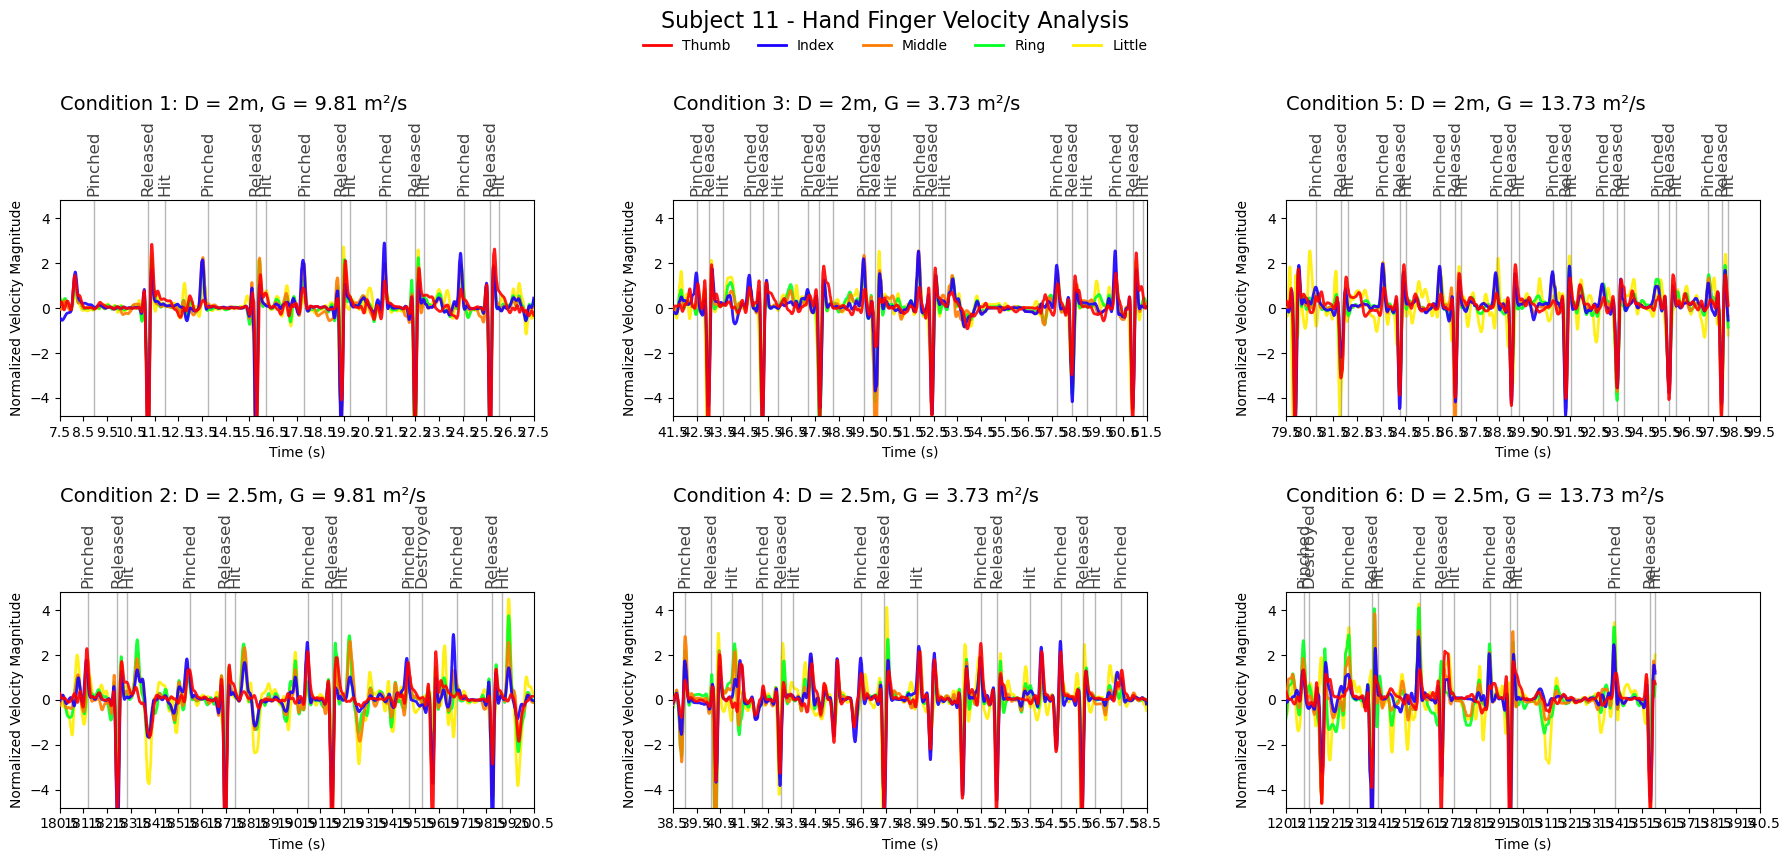

In [77]:
# Process hand position data for each subject
base = current_phase.data_dir / "1_chopped"

for sub in sub_nums:
    all_hand_data = []
    all_markers = []
    PINCH_STARTS = OW_STARTS[sub]
    
    print(f"Processing subject {sub}...")
    
    for sub_dir in sorted(base.glob(f"sub{sub}_*")):
        print(f"  Found directory: {sub_dir}")
        for f in sorted(sub_dir.glob("hand_position_order*_cond*.csv")):
            print(f"    Processing file: {f.name}")
            # Read hand position data
            df = pd.read_csv(f)
            print(f"      Data shape: {df.shape}")
            print(f"      Columns with 'finger': {[col for col in df.columns if 'finger' in col]}")
            
            # Get corresponding marker file
            marker_name = f.name.replace("hand_position_", "marker_")
            marker_path = f.parent / marker_name
            
            if marker_path.exists():
                marker_df = pd.read_csv(marker_path)
                t0_ms = marker_df["UnixTime(ms)"].iloc[0]

                # Convert timestamps to relative time
                # unix_time is in nanoseconds, UnixTime(ms) is in milliseconds
                df["t_rel_s"] = (df["unix_time"] - t0_ms * 1000000) / 1000000000.0  # Convert nanoseconds to seconds
                marker_df["t_rel_s"] = (marker_df["UnixTime(ms)"] - t0_ms) / 1000.0  # Convert milliseconds to seconds
                
                # Debug time synchronization
                print(f"      t0_ms: {t0_ms}")
                print(f"      Data time range: [{df['t_rel_s'].min():.2f}, {df['t_rel_s'].max():.2f}] seconds")
                print(f"      Marker time range: [{marker_df['t_rel_s'].min():.2f}, {marker_df['t_rel_s'].max():.2f}] seconds")
                
                # Add condition information
                if "Condition" in df.columns:
                    all_hand_data.append(df)
                    all_markers.append(marker_df)
                    print(f"      Added data with condition: {df['Condition'].iloc[0]}")
            else:
                print(f"      No marker file found: {marker_path}")
    
    print(f"  Total hand data files: {len(all_hand_data)}")
    
    if all_hand_data:
        title_name = f"Subject {sub} - Hand Finger Velocity Analysis"
        hand_velocity_plotter(PINCH_STARTS, all_hand_data, all_markers, title_name)
    else:
        print(f"No hand position data found for subject {sub}")
